# Active Learning for Frame Weights - ADAPTIVE Variant

"""
This notebook implements an ADAPTIVE active learning algorithm to learn frame weights 
in a multi-frame preference model for kidney allocation decisions.

Key differences from baseline:
- Decision 2 (Query Selection): Frame-targeted querying - identifies frames with high 
  weight uncertainty and generates queries targeting those frames
- Decision 3 (Query Generation): Adaptive uncertainty targeting - generates candidates 
  that activate uncertain frames rather than random generation
- Decision 4 (Stopping Criterion): ε-Pareto guarantee - stops when all rules in H_t 
  are ε-Pareto optimal (using Theorem 3), not just diameter-based

Based on adapting volume-removal active learning (Sadigh et al. 2017) with principled 
stopping criteria from the Pareto optimality framework.
"""

## Key Differences: Baseline vs Adaptive

This notebook implements **3 key adaptive improvements** over the baseline:

### Decision 2: Frame-Targeted Query Selection (Option C)
**Baseline:** Select query with highest uncertainty from **randomly generated** candidates
**Adaptive:** Select query with highest uncertainty from **adaptively generated** candidates targeting uncertain frames

### Decision 3: Adaptive Uncertainty Targeting (Option C)
**Baseline:** Generate candidates by:
- Randomly sampling frame activation patterns
- No consideration of current uncertainties

**Adaptive:** Generate candidates by (`generate_adaptive_candidates`):
1. Compute frame uncertainties (variance) in current feasible set
2. Identify top-K most uncertain frames
3. Generate queries that activate combinations of these uncertain frames
4. Focus queries on resolving current uncertainties

**Key Functions:**
- `compute_frame_uncertainties(samples)` → variance of each frame weight
- `generate_adaptive_candidates(samples, n_candidates, top_k_uncertain)` → queries targeting uncertain frames

### Decision 4: ε-Pareto Guarantee (Option C)
**Baseline:** Stop when `diameter(Ω_t) ≤ ε` (max pairwise L1 distance)
**Adaptive:** Stop when **all rules are ε-Pareto optimal** (using Theorem 3)

**Key Function:**
- `check_epsilon_pareto(samples, epsilon)` → True if max L1 distance ≤ ε

Since V = I (identity), ε-Pareto optimality reduces to diameter check, but provides principled theoretical guarantee that all learned rules are within ε of the Pareto frontier.

### Expected Benefits
1. **Sample Complexity:** Fewer queries needed (adaptive targeting reduces waste)
2. **Accuracy:** Better convergence (focused on uncertainties)
3. **Principled:** ε-Pareto guarantee provides theoretical backing

### Trade-offs
1. **Per-iteration cost:** Slightly higher (compute uncertainties, targeted generation)
2. **Complexity:** More sophisticated logic
3. **Tuning:** Additional parameter `top_k_uncertain` to set

The comparative experiments will reveal if the benefits outweigh the costs.

In [ ]:
# Imports
import numpy as np
import pandas as pd
from typing import List, Tuple, Dict, Set, Optional
from dataclasses import dataclass
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
import seaborn as sns

sns.set_style("whitegrid")
np.random.seed(42)

# Import all core functions and classes
from core import (
    Patient, PairwiseQuery, QueryResponse,
    sample_from_simplex, resample_from_feasible_set,
    compute_stable_convergence_metrics, compute_diameter,
    generate_random_patient, compute_frame_gaps, compute_aggregate_scores,
    predict_response, filter_samples_by_response,
    generate_query_activating_frames, generate_candidate_queries,
    select_query_by_uncertainty,
    compute_frame_uncertainties, generate_adaptive_candidates,
    check_epsilon_pareto,
    active_learning_loop, active_learning_loop_adaptive,
    extract_transcript, fit_bradley_terry,
)

In [3]:
# Feature configuration for kidney allocation domain
FEATURE_NAMES = ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']

# Feature ranges extracted from kidney_pairwise_data.csv
FEATURE_RANGES = {
    'elderlyDep': (0, 5),
    'lifeYearsGained': (0, 25),  # -1 might be missing data indicator
    'obesity': (0, 5),  # Categorical: 0=not obese to 4=very obese  
    'weeklyWorkhours': (0, 50),
    'yearsWaiting': (1, 10)
}

# Algorithm parameters
TAU = 1.0  # Intensity threshold
TAU_PRIME = 0.2  # Resolvability threshold
LAMBDA_X = 1.0  # Query scaling factor (can be a function later)

print("Configuration:")
print(f"  Features: {FEATURE_NAMES}")
print(f"  Thresholds: τ={TAU}, τ'={TAU_PRIME}")
print(f"  λ(X) = {LAMBDA_X}")

Configuration:
  Features: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
  Thresholds: τ=1.0, τ'=0.2
  λ(X) = 1.0


In [4]:
# Data structures: Patient
@dataclass
class Patient:
    """Represents a patient with feature values."""
    elderlyDep: int
    lifeYearsGained: float
    obesity: int
    weeklyWorkhours: int
    yearsWaiting: int

    def to_array(self) -> np.ndarray:
        """Convert to numpy array in standard feature order."""
        return np.array([
            self.elderlyDep,
            self.lifeYearsGained,
            self.obesity,
            self.weeklyWorkhours,
            self.yearsWaiting
        ], dtype=float)

    @classmethod
    def from_array(cls, arr: np.ndarray) -> 'Patient':
        """Create Patient from numpy array."""
        return cls(
            elderlyDep=int(arr[0]),
            lifeYearsGained=float(arr[1]),
            obesity=int(arr[2]),
            weeklyWorkhours=int(arr[3]),
            yearsWaiting=int(arr[4])
        )

    def __repr__(self):
        return f"Patient(elder={self.elderlyDep}, life={self.lifeYearsGained}, " \
               f"obesity={self.obesity}, work={self.weeklyWorkhours}, wait={self.yearsWaiting})"

# Test
p = Patient(elderlyDep=2, lifeYearsGained=15, obesity=1, weeklyWorkhours=40, yearsWaiting=3)
print(p)
print(f"As array: {p.to_array()}")

Patient(elder=2, life=15, obesity=1, work=40, wait=3)
As array: [ 2. 15.  1. 40.  3.]


In [5]:
# Data structures: PairwiseQuery and QueryResponse
@dataclass
class PairwiseQuery:
    """Represents a pairwise comparison query."""
    patient_left: Patient
    patient_right: Patient
    context: Optional[str] = None  # Optional context information X

    def __repr__(self):
        return f"Query:\n  LEFT:  {self.patient_left}\n  RIGHT: {self.patient_right}"


@dataclass
class QueryResponse:
    """Response to a pairwise query."""
    choice: str  # 'left', 'right', 'indifferent', 'incomparable'
    active_frames: Set[int]  # Which frames were active (0-indexed)

    def __repr__(self):
        return f"Response(choice={self.choice}, active_frames={self.active_frames})"

# Test
p1 = Patient(elderlyDep=2, lifeYearsGained=15, obesity=1, weeklyWorkhours=40, yearsWaiting=3)
p2 = Patient(elderlyDep=0, lifeYearsGained=20, obesity=3, weeklyWorkhours=30, yearsWaiting=5)
query = PairwiseQuery(p1, p2)
print(query)
print()
response = QueryResponse(choice='left', active_frames={0, 1, 4})
print(response)

Query:
  LEFT:  Patient(elder=2, life=15, obesity=1, work=40, wait=3)
  RIGHT: Patient(elder=0, life=20, obesity=3, work=30, wait=5)

Response(choice=left, active_frames={0, 1, 4})


In [6]:
# Simplex sampling: sample_from_simplex
def sample_from_simplex(n_samples: int, dim: int,
                       active_frames: Optional[Set[int]] = None,
                       random_state: Optional[int] = None) -> np.ndarray:
    """
    Sample uniformly from the probability simplex.

    Uses the Dirichlet distribution with α=1 (uniform on simplex).

    Parameters:
    -----------
    n_samples : int
        Number of samples to generate
    dim : int
        Dimension of simplex (number of frames)
    active_frames : Set[int], optional
        If provided, only these frames can have non-zero weight
    random_state : int, optional
        Random seed for reproducibility

    Returns:
    --------
    samples : np.ndarray, shape (n_samples, dim)
        Samples from the simplex, each row sums to 1
    """
    if random_state is not None:
        np.random.seed(random_state)

    if active_frames is None:
        # Sample from full simplex
        samples = np.random.dirichlet(np.ones(dim), size=n_samples)
    else:
        # Only sample on sub-simplex for active frames
        samples = np.zeros((n_samples, dim))
        active_list = sorted(list(active_frames))
        n_active = len(active_list)

        if n_active == 0:
            raise ValueError("Must have at least one active frame")

        # Sample from sub-simplex
        sub_samples = np.random.dirichlet(np.ones(n_active), size=n_samples)

        # Place in correct positions
        for i, frame_idx in enumerate(active_list):
            samples[:, frame_idx] = sub_samples[:, i]

    return samples

# Test
samples = sample_from_simplex(10, 5, random_state=42)
print("Full simplex samples:")
print(samples[:3])
print(f"Row sums: {samples.sum(axis=1)[:3]}")
print()
samples_subset = sample_from_simplex(10, 5, active_frames={0, 2, 4}, random_state=42)
print("Sub-simplex samples (frames {0, 2, 4} only):")
print(samples_subset[:3])

Full simplex samples:
[[0.07982511 0.51203839 0.22398576 0.1552966  0.02885413]
 [0.03862363 0.0136276  0.45803501 0.20931053 0.28040323]
 [0.00361717 0.60929814 0.31067514 0.04150979 0.03489977]]
Row sums: [1. 1. 1.]

Sub-simplex samples (frames {0, 2, 4} only):
[[0.09784297 0.         0.62761396 0.         0.27454307]
 [0.729092   0.         0.13546541 0.         0.13544259]
 [0.02001195 0.         0.67261832 0.         0.30736973]]


In [7]:
# Simplex sampling: resample_from_feasible_set
def resample_from_feasible_set(existing_samples: np.ndarray,
                               target_n_samples: int,
                               noise_scale: float = 0.05) -> np.ndarray:
    """
    Generate new samples by perturbing existing feasible samples.

    This is used when we've filtered out too many samples and need to replenish.

    Parameters:
    -----------
    existing_samples : np.ndarray, shape (n_existing, dim)
        Current feasible samples
    target_n_samples : int
        Desired number of samples
    noise_scale : float
        Scale of Gaussian noise to add before re-normalizing

    Returns:
    --------
    new_samples : np.ndarray, shape (target_n_samples, dim)
        Resampled feasible set
    """
    n_existing, dim = existing_samples.shape

    # Resample with replacement
    indices = np.random.choice(n_existing, size=target_n_samples, replace=True)
    new_samples = existing_samples[indices].copy()

    # Add noise and re-project to simplex
    noise = np.random.randn(target_n_samples, dim) * noise_scale
    new_samples = new_samples + noise
    new_samples = np.maximum(new_samples, 0)  # Ensure non-negative

    # Re-normalize to simplex
    row_sums = new_samples.sum(axis=1, keepdims=True)
    new_samples = new_samples / np.maximum(row_sums, 1e-10)

    return new_samples

# Test
small_samples = sample_from_simplex(5, 5, random_state=42)
print("Original 5 samples:")
print(small_samples)
print()
resampled = resample_from_feasible_set(small_samples, target_n_samples=10, noise_scale=0.05)
print("Resampled to 10:")
print(resampled)

Original 5 samples:
[[0.07982511 0.51203839 0.22398576 0.1552966  0.02885413]
 [0.03862363 0.0136276  0.45803501 0.20931053 0.28040323]
 [0.00361717 0.60929814 0.31067514 0.04150979 0.03489977]
 [0.09130535 0.16347231 0.33524563 0.25485514 0.15512157]
 [0.37744127 0.05991806 0.13780201 0.18197713 0.24286153]]

Resampled to 10:
[[0.         0.66221368 0.32797237 0.00981396 0.        ]
 [0.08553135 0.14059315 0.34428266 0.25014958 0.17944326]
 [0.0233575  0.18159446 0.39484708 0.26192367 0.13827728]
 [0.13377982 0.49833804 0.15635252 0.20942753 0.00210209]
 [0.         0.60673709 0.27279197 0.05176951 0.06870143]
 [0.38866694 0.0964089  0.16175102 0.15812714 0.19504599]
 [0.         0.61453668 0.27918948 0.01941877 0.08685508]
 [0.34784446 0.10633934 0.15965895 0.13607629 0.25008097]
 [0.09525546 0.40914105 0.22151128 0.12768048 0.14641173]
 [0.         0.         0.49140882 0.14944822 0.35914295]]


In [8]:
# Alternative Convergence Metrics (less noisy than max_distance)
def compute_stable_convergence_metrics(samples: np.ndarray) -> dict:
    """
    Compute convergence metrics that are less affected by resampling noise.
    
    These metrics are more stable than max pairwise distance:
    - Weight variance: measures spread along each dimension
    - Average distance: less sensitive to outliers than max
    - Median distance: robust to extreme points
    """
    if len(samples) == 0:
        return {'variance': float('inf'), 'avg_distance': float('inf'), 'median_distance': float('inf')}
    
    # 1. Total variance across all dimensions
    variance = np.sum(np.var(samples, axis=0))
    
    # 2. Average pairwise distance (sample a subset to avoid O(n²))
    n_pairs = min(1000, len(samples) * (len(samples) - 1) // 2)
    if len(samples) > 50:
        # Sample random pairs
        idx1 = np.random.choice(len(samples), n_pairs)
        idx2 = np.random.choice(len(samples), n_pairs)
        distances = np.linalg.norm(samples[idx1] - samples[idx2], axis=1)
    else:
        # Compute all pairs
        from scipy.spatial.distance import pdist
        distances = pdist(samples)
    
    avg_distance = np.mean(distances)
    median_distance = np.median(distances)
    
    return {
        'variance': variance,
        'avg_distance': avg_distance,
        'median_distance': median_distance
    }

# Test
test_samples = sample_from_simplex(100, 5, random_state=42)
metrics = compute_stable_convergence_metrics(test_samples)
print("Stable convergence metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

Stable convergence metrics:
  variance: 0.1387
  avg_distance: 0.4922
  median_distance: 0.4844


In [ ]:
# Simplex sampling: compute_diameter
def compute_diameter(samples: np.ndarray, norm: str = 'l1') -> float:
    """
    Compute diameter of a set of samples.

    Parameters:
    -----------
    samples : np.ndarray, shape (n_samples, dim)
        Sample points
    norm : str
        Which norm to use: 'l1', 'l2', or 'linf'

    Returns:
    --------
    diameter : float
        Maximum pairwise distance
    """
    if len(samples) == 0:
        return 0.0

    if len(samples) == 1:
        return 0.0

    # Compute all pairwise distances
    if norm == 'l1':
        p = 1
    elif norm == 'l2':
        p = 2
    elif norm == 'linf':
        p = np.inf
    else:
        raise ValueError(f"Unknown norm: {norm}")

    distances = pdist(samples, metric='minkowski', p=p)

    return distances.max()

# # Test
# samples = sample_from_simplex(100, 5, random_state=42)
# print(f"Diameter (L1) of 100 samples on 5D simplex: {compute_diameter(samples, 'l1'):.4f}")
# print(f"Diameter (L2) of 100 samples on 5D simplex: {compute_diameter(samples, 'l2'):.4f}")

# # Smaller feasible set
# small_samples = sample_from_simplex(100, 5, active_frames={0, 1}, random_state=42)
# print(f"\nDiameter (L1) when only 2 frames active: {compute_diameter(small_samples, 'l1'):.4f}")

Diameter (L1) of 100 samples on 5D simplex: 1.8028
Diameter (L2) of 100 samples on 5D simplex: 1.0742

Diameter (L1) when only 2 frames active: 1.9643


In [ ]:
# Query generation: generate_random_patient
def generate_random_patient() -> Patient:
    """Generate a random patient with features in valid ranges."""
    return Patient(
        elderlyDep=np.random.randint(0, 5),
        lifeYearsGained=np.random.randint(0,25),
        obesity=np.random.randint(0, 5),
        weeklyWorkhours=np.random.randint(0, 50),
        yearsWaiting=np.random.randint(1, 10)
    )

# # Test
# print("Random patients:")
# for _ in range(3):
#     print(f"  {generate_random_patient()}")

Random patients:
  Patient(elder=3, life=10, obesity=0, work=7, wait=4)
  Patient(elder=3, life=2, obesity=0, work=34, wait=9)
  Patient(elder=4, life=17, obesity=1, work=1, wait=6)


In [11]:
# Core computations: compute_frame_gaps
def compute_frame_gaps(query: PairwiseQuery,
                      lambda_x: float = LAMBDA_X,
                      tau: float = TAU) -> Tuple[np.ndarray, Set[int]]:
    """
    Compute frame-level gaps and identify active (decisive) frames for a query.

    In the linear setting with V = I:
        Δ_j = λ(X) × [feature_j(left) - feature_j(right)]

    For a frame j:
        s^+_j = max(Δ_j, 0)
        s^-_j = max(-Δ_j, 0)

    A frame j is active (decisive) if s^+_j + s^-_j ≥ τ, i.e., |Δ_j| ≥ τ

    Parameters:
    -----------
    query : PairwiseQuery
        The pairwise comparison query
    lambda_x : float
        Query scaling factor (default: LAMBDA_X)
    tau : float
        Intensity threshold (default: TAU)

    Returns:
    --------
    gaps : np.ndarray, shape (n_frames,)
        Frame-level preference gaps Δ_j
    active_frames : Set[int]
        Indices of frames where |Δ_j| ≥ τ (frame is decisive)
    """
    # Get feature vectors
    left_features = query.patient_left.to_array()
    right_features = query.patient_right.to_array()

    # Compute gaps: Δ_j = λ(X) × (left - right)
    gaps = lambda_x * (left_features - right_features)

    # Identify active frames: frame j is active if |Δ_j| ≥ τ
    active_frames = set(np.where(np.abs(gaps) >= tau)[0].tolist())

    return gaps, active_frames

# Test
p1 = Patient(elderlyDep=2, lifeYearsGained=15, obesity=1, weeklyWorkhours=40, yearsWaiting=3)
p2 = Patient(elderlyDep=0, lifeYearsGained=20, obesity=3, weeklyWorkhours=30, yearsWaiting=5)
query = PairwiseQuery(p1, p2)

gaps, active = compute_frame_gaps(query)
print(f"Query: elder={p1.elderlyDep} vs {p2.elderlyDep}, life={p1.lifeYearsGained} vs {p2.lifeYearsGained}")
print(f"Frame gaps Δ: {gaps}")
print(f"Active frames (|Δ_j| ≥ {TAU}): {sorted(active)}")
print(f"  Features: {[FEATURE_NAMES[i] for i in sorted(active)]}")

Query: elder=2 vs 0, life=15 vs 20
Frame gaps Δ: [ 2. -5. -2. 10. -2.]
Active frames (|Δ_j| ≥ 1.0): [0, 1, 2, 3, 4]
  Features: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']


In [12]:
# Core computations: compute_aggregate_scores
def compute_aggregate_scores(gaps: np.ndarray, 
                             weights: np.ndarray,
                             active_frames: Set[int]) -> Tuple[float, float]:
    """
    Compute aggregate preference score and intensity for given weights.
    
    For a weight vector ω and frame gaps Δ:
        Δ(ω) = Σ_{j∈active} ω_j × Δ_j    (signed preference)
        r(ω) = Σ_{j∈active} ω_j × |Δ_j|  (intensity, always >= 0)
    
    Parameters:
    -----------
    gaps : np.ndarray, shape (n_frames,)
        Frame-level preference gaps Δ_j
    weights : np.ndarray, shape (n_frames,)
        Frame weights ω (should sum to 1)
    active_frames : Set[int]
        Indices of active frames
    
    Returns:
    --------
    delta_omega : float
        Aggregate preference score Δ(ω)
    r_omega : float
        Aggregate intensity r(ω)
    """
    if len(active_frames) == 0:
        return 0.0, 0.0
    
    # Only consider active frames
    active_list = sorted(list(active_frames))
    active_gaps = gaps[active_list]
    active_weights = weights[active_list]
    
    # Compute weighted sums
    delta_omega = np.dot(active_weights, active_gaps)
    r_omega = np.dot(active_weights, np.abs(active_gaps))
    
    return delta_omega, r_omega

# Test
gaps = np.array([2.0, -5.0, -2.0, 10.0, -2.0])  # Frame gaps
active = {0, 1, 3, 4}  # Frames 0, 1, 3, 4 are active
weights = np.array([0.2, 0.3, 0.0, 0.4, 0.1])  # Weight on simplex

delta, r = compute_aggregate_scores(gaps, weights, active)
print(f"Gaps: {gaps}")
print(f"Weights: {weights}")
print(f"Active frames: {sorted(active)}")
print(f"Δ(ω) = {delta:.3f} (signed preference)")
print(f"r(ω) = {r:.3f} (intensity)")
print(f"\nManual check:")
print(f"  Δ(ω) = 0.2×{gaps[0]} + 0.3×{gaps[1]} + 0.4×{gaps[3]} + 0.1×{gaps[4]} = {0.2*gaps[0] + 0.3*gaps[1] + 0.4*gaps[3] + 0.1*gaps[4]:.3f}")

Gaps: [ 2. -5. -2. 10. -2.]
Weights: [0.2 0.3 0.  0.4 0.1]
Active frames: [0, 1, 3, 4]
Δ(ω) = 2.700 (signed preference)
r(ω) = 6.100 (intensity)

Manual check:
  Δ(ω) = 0.2×2.0 + 0.3×-5.0 + 0.4×10.0 + 0.1×-2.0 = 2.700


In [ ]:
# Core computations: predict_response
def predict_response(query: PairwiseQuery,
                    weights: np.ndarray,
                    tau: float = TAU,
                    lambda_x: float = LAMBDA_X,
                    tau_prime: float = TAU_PRIME) -> str:
    """
    Predict the response for a query given a weight vector.
    
    Decision rule:
        - If r(ω) ≤ τ: 'indifferent' (intensity too low)
        - Else if |Δ(ω)| / r(ω) < τ': 'incomparable' (not resolvable)
        - Else if Δ(ω) > 0: 'left' (prefer left patient)
        - Else if Δ(ω) < 0: 'right' (prefer right patient)
        - Else: 'indifferent' (Δ(ω) = 0)
    
    Parameters:
    -----------
    query : PairwiseQuery
        The pairwise comparison query
    weights : np.ndarray, shape (n_frames,)
        Frame weights ω
    tau : float
        Intensity threshold (default: TAU)
    lambda_x : float
        Query scaling factor (default: LAMBDA_X)
    tau_prime : float
        Resolvability threshold (default: TAU_PRIME)
    
    Returns:
    --------
    response : str
        One of: 'left', 'right', 'indifferent', 'incomparable'
    """
    # Compute frame gaps and active frames
    gaps, active_frames = compute_frame_gaps(query, lambda_x, tau)
    
    # Compute aggregate scores
    delta_omega, r_omega = compute_aggregate_scores(gaps, weights, active_frames)
    
    # Apply decision rule
    if r_omega < tau:
        return 'indifferent'
    if  r_omega >= tau and np.abs(delta_omega) < tau_prime * r_omega:
        # Not resolvable: |Δ(ω)| < τ' * r(ω)
        return 'incomparable'
    elif r_omega >= tau and delta_omega >= tau_prime * r_omega:
        return 'left'
    elif r_omega >= tau and delta_omega <= -tau_prime * r_omega:
        return 'right'
    else:
        return 'indifferent'

# Test
p1 = Patient(elderlyDep=2, lifeYearsGained=0, obesity=1, weeklyWorkhours=40, yearsWaiting=5)
p2 = Patient(elderlyDep=0, lifeYearsGained=15, obesity=3, weeklyWorkhours=30, yearsWaiting=3)
query = PairwiseQuery(p1, p2)

# Test different weight vectors
w1 = np.array([0.6, 0.1, 0.1, 0.1, 0.1])  # Heavy on elderlyDep (frame 0)
w2 = np.array([0.1, 0.6, 0.1, 0.1, 0.1])  # Heavy on lifeYearsGained (frame 1)
w3 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])  # Uniform

print(f"Query: {p1} vs {p2}")
print(f"\nWeight w1 (heavy on elderlyDep): {w1}")
print(f"  Predicted response: {predict_response(query, w1)}")
print(f"\nWeight w2 (heavy on lifeYearsGained): {w2}")
print(f"  Predicted response: {predict_response(query, w2)}")
print(f"\nWeight w3 (uniform): {w3}")
print(f"  Predicted response: {predict_response(query, w3)}")

Query: Patient(elder=2, life=0, obesity=1, work=40, wait=5) vs Patient(elder=0, life=15, obesity=3, work=30, wait=3)

Weight w1 (heavy on elderlyDep): [0.6 0.1 0.1 0.1 0.1]
  Predicted response: incomparable

Weight w2 (heavy on lifeYearsGained): [0.1 0.6 0.1 0.1 0.1]
  Predicted response: right

Weight w3 (uniform): [0.2 0.2 0.2 0.2 0.2]
  Predicted response: incomparable


In [14]:
# Volume removal: filter_samples_by_response
def filter_samples_by_response(samples: np.ndarray,
                               query: PairwiseQuery,
                               observed_response: str,
                               tau: float = TAU,
                               lambda_x: float = LAMBDA_X,
                               tau_prime: float = TAU_PRIME) -> np.ndarray:
    """
    Filter samples to keep only those consistent with observed response.
    
    This is the volume removal step: we eliminate all weight vectors
    that would have predicted a different response.
    
    Parameters:
    -----------
    samples : np.ndarray, shape (n_samples, dim)
        Current feasible weight vectors
    query : PairwiseQuery
        The query that was asked
    observed_response : str
        The response observed: 'left', 'right', 'indifferent', or 'incomparable'
    tau : float
        Intensity threshold
    lambda_x : float
        Query scaling factor
    tau_prime : float
        Resolvability threshold
    
    Returns:
    --------
    filtered_samples : np.ndarray, shape (n_consistent, dim)
        Weight vectors consistent with the observed response
    """
    # Compute gaps and active frames once
    gaps, active_frames = compute_frame_gaps(query, lambda_x, tau)
    
    # Vectorized computation of aggregate scores for all samples
    if len(active_frames) == 0:
        # No active frames - all would respond 'incomparable'
        if observed_response == 'incomparable':
            return samples
        else:
            return np.empty((0, samples.shape[1]))
    
    active_list = sorted(list(active_frames))
    active_gaps = gaps[active_list]
    
    # Compute delta_omega and r_omega for all samples at once
    active_weights = samples[:, active_list]
    delta_omegas = np.dot(active_weights, active_gaps)
    r_omegas = np.dot(active_weights, np.abs(active_gaps))
    
    # Determine predicted responses for all samples using CORRECTED logic
    # Match the logic in predict_response function
    predicted = np.empty(len(samples), dtype=object)
    
    # Apply corrected decision rule for each sample
    for idx in range(len(samples)):
        r_omega = r_omegas[idx]
        delta_omega = delta_omegas[idx]
        
        if r_omega < tau:
            predicted[idx] = 'indifferent'
        elif r_omega >= tau and np.abs(delta_omega) < tau_prime * r_omega:
            predicted[idx] = 'incomparable'
        elif r_omega >= tau and delta_omega >= tau_prime * r_omega:
            predicted[idx] = 'left'
        elif r_omega >= tau and delta_omega <= -tau_prime * r_omega:
            predicted[idx] = 'right'
        else:
            predicted[idx] = 'indifferent'
    
    # Keep only consistent samples
    consistent_mask = (predicted == observed_response)
    filtered_samples = samples[consistent_mask]
    
    return filtered_samples

# Test
samples = sample_from_simplex(1000, 5, random_state=42)
p1 = Patient(elderlyDep=2, lifeYearsGained=20, obesity=1, weeklyWorkhours=40, yearsWaiting=5)
p2 = Patient(elderlyDep=0, lifeYearsGained=15, obesity=3, weeklyWorkhours=30, yearsWaiting=3)
query = PairwiseQuery(p1, p2)

print(f"Initial samples: {len(samples)}")

# Simulate observing "left" response
filtered = filter_samples_by_response(samples, query, 'left')
print(f"After observing 'left': {len(filtered)} samples remaining ({100*len(filtered)/len(samples):.1f}%)")

# Further filter with another query
p3 = Patient(elderlyDep=3, lifeYearsGained=10, obesity=4, weeklyWorkhours=20, yearsWaiting=7)
p4 = Patient(elderlyDep=1, lifeYearsGained=25, obesity=0, weeklyWorkhours=50, yearsWaiting=1)
query2 = PairwiseQuery(p3, p4)
filtered2 = filter_samples_by_response(filtered, query2, 'right')
print(f"After observing 'right' to 2nd query: {len(filtered2)} samples ({100*len(filtered2)/len(samples):.1f}%)")

Initial samples: 1000
After observing 'left': 976 samples remaining (97.6%)
After observing 'right' to 2nd query: 811 samples (81.1%)


In [15]:
# Query generation: generate_query_activating_frames
def generate_query_activating_frames(target_frames: Set[int],
                                    lambda_x: float = LAMBDA_X,
                                    tau: float = TAU,
                                    min_gap: float = None,
                                    max_attempts: int = 100) -> Optional[PairwiseQuery]:
    """
    Generate a query that activates a specific subset of frames.
    
    Strategy:
    - For frames in target_frames: set |Δ_j| ≥ τ (make them active/decisive)
    - For frames not in target_frames: set |Δ_j| < τ (make them inactive)
    
    Parameters:
    -----------
    target_frames : Set[int]
        Indices of frames to activate (0-indexed)
    lambda_x : float
        Query scaling factor
    tau : float
        Intensity threshold
    min_gap : float, optional
        Minimum gap for active frames (default: 1.5 * tau)
    max_attempts : int
        Maximum number of random attempts
    
    Returns:
    --------
    query : PairwiseQuery or None
        A query activating the target frames, or None if failed
    """
    if min_gap is None:
        min_gap = 1.5 * tau
    
    n_features = len(FEATURE_NAMES)
    
    for attempt in range(max_attempts):
        # Generate random left patient
        left = generate_random_patient()
        left_arr = left.to_array()
        
        # Construct right patient to achieve desired activation
        right_arr = left_arr.copy()
        
        for j in range(n_features):
            feature_name = FEATURE_NAMES[j]
            min_val, max_val = FEATURE_RANGES[feature_name]
            
            if j in target_frames:
                # Make this frame active: |Δ_j| ≥ τ
                # Need |left[j] - right[j]| * lambda_x >= tau
                required_diff = min_gap / lambda_x
                
                # Try to create difference
                if left_arr[j] + required_diff <= max_val:
                    right_arr[j] = left_arr[j] - required_diff
                elif left_arr[j] - required_diff >= min_val:
                    right_arr[j] = left_arr[j] + required_diff
                else:
                    # Can't achieve required difference - try next attempt
                    break
            else:
                # Make this frame inactive: |Δ_j| < τ
                # Set right[j] ≈ left[j] (small or no difference)
                max_diff = tau / lambda_x * 0.8  # Stay safely below threshold
                diff = np.random.uniform(-max_diff, max_diff)
                right_arr[j] = np.clip(left_arr[j] + diff, min_val, max_val)
        else:
            # All features successfully set - validate
            right = Patient.from_array(right_arr)
            query = PairwiseQuery(left, right)
            
            # Check if it actually activates the correct frames
            _, active = compute_frame_gaps(query, lambda_x, tau)
            if active == target_frames:
                return query
    
    # Failed to generate query after max_attempts
    return None

# Test
print("Generating queries with specific frame activations:\n")

# Query activating only frames {0, 2} (elderlyDep, obesity)
query1 = generate_query_activating_frames({0, 2})
if query1:
    gaps, active = compute_frame_gaps(query1)
    print(f"Target frames: {{0, 2}}")
    print(f"  {query1}")
    print(f"  Gaps: {gaps}")
    print(f"  Active: {active} ✓" if active == {0, 2} else f"  Active: {active} ✗")

print()

# Query activating frames {1, 4} (lifeYearsGained, yearsWaiting)
query2 = generate_query_activating_frames({1, 4})
if query2:
    gaps, active = compute_frame_gaps(query2)
    print(f"Target frames: {{1, 4}}")
    print(f"  {query2}")
    print(f"  Gaps: {gaps}")
    print(f"  Active: {active} ✓" if active == {1, 4} else f"  Active: {active} ✗")

Generating queries with specific frame activations:

Target frames: {0, 2}
  Query:
  LEFT:  Patient(elder=2, life=4, obesity=2, work=14, wait=3)
  RIGHT: Patient(elder=0, life=3.464799639461849, obesity=0, work=14, wait=3)
  Gaps: [2.         0.53520036 2.         0.         0.        ]
  Active: {0, 2} ✓

Target frames: {1, 4}
  Query:
  LEFT:  Patient(elder=2, life=5, obesity=0, work=25, wait=5)
  RIGHT: Patient(elder=2, life=3.5, obesity=0, work=25, wait=3)
  Gaps: [0.  1.5 0.  0.  2. ]
  Active: {1, 4} ✓


In [16]:
# Query generation: generate_candidate_queries
def generate_candidate_queries(n_candidates: int = 50,
                               n_features: int = 5,
                               max_active: int = None) -> List[PairwiseQuery]:
    """
    Generate a diverse pool of candidate queries.
    
    Strategy:
    - Sample different frame activation patterns
    - Generate queries for each pattern
    - Prioritize patterns with moderate numbers of active frames
    
    Parameters:
    -----------
    n_candidates : int
        Target number of candidate queries
    n_features : int
        Number of features/frames
    max_active : int, optional
        Maximum number of active frames (default: n_features)
    
    Returns:
    --------
    candidates : List[PairwiseQuery]
        List of candidate queries
    """
    if max_active is None:
        max_active = n_features
    
    candidates = []
    attempted_patterns = set()
    
    # Try to generate diverse activation patterns
    max_attempts = n_candidates * 3
    
    for _ in range(max_attempts):
        if len(candidates) >= n_candidates:
            break
        
        # Choose number of active frames (prefer 2-4)
        if np.random.random() < 0.7:
            # Moderate number
            n_active = np.random.randint(2, min(5, max_active + 1))
        else:
            # Full range
            n_active = np.random.randint(1, max_active + 1)
        
        # Sample which frames to activate
        target_frames = set(np.random.choice(n_features, size=n_active, replace=False).tolist())
        
        # Skip if we've tried this pattern
        pattern_key = frozenset(target_frames)
        if pattern_key in attempted_patterns:
            continue
        
        attempted_patterns.add(pattern_key)
        
        # Try to generate query
        query = generate_query_activating_frames(target_frames)
        if query is not None:
            candidates.append(query)
    
    # If we didn't get enough, add some random queries
    while len(candidates) < n_candidates * 0.5:
        left = generate_random_patient()
        right = generate_random_patient()
        candidates.append(PairwiseQuery(left, right))
    
    return candidates

# Test
print("Generating candidate queries...\n")
candidates = generate_candidate_queries(n_candidates=20)

print(f"Generated {len(candidates)} candidate queries\n")

# Analyze activation patterns
activation_counts = {}
for query in candidates:
    _, active = compute_frame_gaps(query)
    n_active = len(active)
    activation_counts[n_active] = activation_counts.get(n_active, 0) + 1

print("Distribution of active frame counts:")
for n_active in sorted(activation_counts.keys()):
    print(f"  {n_active} frames active: {activation_counts[n_active]} queries")

# Show a few examples
print(f"\nFirst 3 candidate queries:")
for i, query in enumerate(candidates[:3]):
    gaps, active = compute_frame_gaps(query)
    print(f"\n{i+1}. Active frames: {sorted(active)}")
    print(f"   {query}")
    print(f"   Gaps: {gaps}")

Generating candidate queries...

Generated 20 candidate queries

Distribution of active frame counts:
  1 frames active: 1 queries
  2 frames active: 7 queries
  3 frames active: 6 queries
  4 frames active: 5 queries
  5 frames active: 1 queries

First 3 candidate queries:

1. Active frames: [0, 1, 2, 3, 4]
   Query:
  LEFT:  Patient(elder=1, life=11, obesity=3, work=45, wait=2)
  RIGHT: Patient(elder=0, life=9.5, obesity=1, work=43, wait=0)
   Gaps: [1.  1.5 2.  2.  2. ]

2. Active frames: [1, 2, 3]
   Query:
  LEFT:  Patient(elder=4, life=21, obesity=0, work=3, wait=2)
  RIGHT: Patient(elder=4, life=19.5, obesity=-1, work=1, wait=2)
   Gaps: [0.  1.5 1.  2.  0. ]

3. Active frames: [0, 1]
   Query:
  LEFT:  Patient(elder=3, life=23, obesity=1, work=7, wait=2)
  RIGHT: Patient(elder=1, life=21.5, obesity=1, work=7, wait=2)
   Gaps: [2.  1.5 0.  0.  0. ]


In [17]:
# Query selection: select_query_by_uncertainty
def select_query_by_uncertainty(candidates: List[PairwiseQuery],
                                samples: np.ndarray,
                                tau: float = TAU,
                                lambda_x: float = LAMBDA_X,
                                tau_prime: float = TAU_PRIME) -> Tuple[PairwiseQuery, Dict[str, float]]:
    """
    Select the query that maximizes uncertainty (best splits the feasible set).
    
    For each candidate query, we:
    1. Predict responses for all samples in the feasible set
    2. Compute uncertainty based on response distribution
    3. Select query with highest uncertainty
    
    Uncertainty measure: entropy of response distribution
        H = -Σ p_r log(p_r) where p_r = fraction predicting response r
    
    Parameters:
    -----------
    candidates : List[PairwiseQuery]
        Candidate queries to choose from
    samples : np.ndarray, shape (n_samples, dim)
        Current feasible weight vectors
    tau : float
        Intensity threshold
    lambda_x : float
        Query scaling factor
    tau_prime : float
        Resolvability threshold
    
    Returns:
    --------
    best_query : PairwiseQuery
        Query with highest uncertainty
    info : Dict[str, float]
        Information about the selected query (uncertainty, response counts)
    """
    if len(candidates) == 0:
        raise ValueError("No candidate queries provided")
    
    if len(samples) == 0:
        # No samples - just return first candidate
        return candidates[0], {'uncertainty': 0.0}
    
    best_query = None
    best_uncertainty = -1
    best_info = {}
    
    for query in candidates:
        # Compute gaps and active frames once
        gaps, active_frames = compute_frame_gaps(query, lambda_x, tau)
        
        if len(active_frames) == 0:
            # All samples would respond 'incomparable' - no information
            continue
        
        # Vectorized prediction for all samples
        active_list = sorted(list(active_frames))
        active_gaps = gaps[active_list]
        active_weights = samples[:, active_list]
        
        delta_omegas = np.dot(active_weights, active_gaps)
        r_omegas = np.dot(active_weights, np.abs(active_gaps))
        
        # Count responses using CORRECTED logic (matches predict_response)
        response_counts = {'left': 0, 'right': 0, 'indifferent': 0, 'incomparable': 0}
        
        # Apply corrected decision rule
        for idx in range(len(samples)):
            r_omega = r_omegas[idx]
            delta_omega = delta_omegas[idx]
            
            if r_omega < tau:
                response_counts['indifferent'] += 1
            elif r_omega >= tau and np.abs(delta_omega) < tau_prime * r_omega:
                response_counts['incomparable'] += 1
            elif r_omega >= tau and delta_omega >= tau_prime * r_omega:
                response_counts['left'] += 1
            elif r_omega >= tau and delta_omega <= -tau_prime * r_omega:
                response_counts['right'] += 1
            else:
                response_counts['indifferent'] += 1
        
        
        # Compute entropy
        total = len(samples)
        probs = [count / total for count in response_counts.values() if count > 0]
        
        if len(probs) <= 1:
            # All samples predict same response - no uncertainty
            uncertainty = 0.0
        else:
            # Entropy: H = -Σ p log(p)
            uncertainty = -sum(p * np.log2(p) for p in probs)
        
        # Track best
        if uncertainty > best_uncertainty:
            best_uncertainty = uncertainty
            best_query = query
            best_info = {
                'uncertainty': uncertainty,
                'response_counts': response_counts.copy(),
                'active_frames': active_frames
            }
    
    if best_query is None:
        # Fallback: return first candidate
        best_query = candidates[0]
        best_info = {'uncertainty': 0.0}
    
    return best_query, best_info

# Test
samples = sample_from_simplex(1000, 5, random_state=42)
candidates = generate_candidate_queries(n_candidates=10)

print(f"Selecting query from {len(candidates)} candidates...\n")

best_query, info = select_query_by_uncertainty(candidates, samples)

print(f"Selected query:")
print(f"{best_query}")
print(f"\nUncertainty: {info['uncertainty']:.3f} bits")
print(f"Active frames: {sorted(info.get('active_frames', set()))}")
print(f"Response distribution:")
for response, count in info.get('response_counts', {}).items():
    if count > 0:
        pct = 100 * count / len(samples)
        print(f"  {response}: {count} ({pct:.1f}%)")

Selecting query from 10 candidates...

Selected query:
Query:
  LEFT:  Patient(elder=3, life=24, obesity=3, work=33, wait=4)
  RIGHT: Patient(elder=1, life=25.5, obesity=3, work=33, wait=2)

Uncertainty: 1.604 bits
Active frames: [0, 1, 4]
Response distribution:
  left: 484 (48.4%)
  right: 64 (6.4%)
  indifferent: 362 (36.2%)
  incomparable: 90 (9.0%)


In [18]:
# Main algorithm: active_learning_loop
def active_learning_loop(n_initial_samples: int = 5000,
                        convergence_diameter: float = 0.1,
                        max_iterations: int = 100,
                        n_candidates: int = 50,
                        min_samples: int = 100,
                        resample_threshold: int = 50,
                        oracle_weights: Optional[np.ndarray] = None,
                        verbose: bool = True) -> Tuple[np.ndarray, List[Dict]]:
    """
    Active learning algorithm to learn frame weights.
    
    Algorithm:
    1. Initialize feasible set with uniform samples on simplex
    2. While diameter > threshold and iterations < max:
        a. Generate candidate queries
        b. Select query with highest uncertainty
        c. Get response from oracle (user or simulated)
        d. Filter feasible set to consistent samples
        e. Resample if needed
        f. Track diameter
    3. Return learned weights (mean of feasible set)
    
    Parameters:
    -----------
    n_initial_samples : int
        Initial number of samples
    convergence_diameter : float
        Convergence threshold (L1 diameter)
    max_iterations : int
        Maximum number of queries
    n_candidates : int
        Number of candidate queries per iteration
    min_samples : int
        Minimum samples to maintain
    resample_threshold : int
        Resample if samples drop below this
    oracle_weights : np.ndarray, optional
        Ground truth weights for simulation (if None, will prompt user)
    verbose : bool
        Print progress
    
    Returns:
    --------
    learned_weights : np.ndarray
        Learned frame weights (mean of feasible set)
    history : List[Dict]
        History of iterations (queries, responses, diameters, etc.)
    """
    n_features = len(FEATURE_NAMES)
    
    # Initialize feasible set
    samples = sample_from_simplex(n_initial_samples, n_features, random_state=42)
    
    history = []
    
    if verbose:
        print(f"Active Learning for Frame Weights")
        print(f"{'='*60}")
        print(f"Initial samples: {len(samples)}")
        print(f"Convergence threshold: {convergence_diameter} (L1 diameter)")
        print(f"Max iterations: {max_iterations}\n")
    
    for iteration in range(max_iterations):
        # Check convergence
        diameter = compute_diameter(samples, norm='l1')
        
        if verbose:
            print(f"Iteration {iteration + 1}")
            print(f"  Feasible samples: {len(samples)}")
            print(f"  Diameter: {diameter:.4f}")
        
        if diameter <= convergence_diameter:
            if verbose:
                print(f"\n✓ Converged! Diameter {diameter:.4f} ≤ {convergence_diameter}")
            break
        
        # Generate candidate queries
        candidates = generate_candidate_queries(n_candidates=n_candidates)
        
        if len(candidates) == 0:
            if verbose:
                print("  Warning: No valid candidates generated")
            break
        
        # Select best query
        query, query_info = select_query_by_uncertainty(candidates, samples)
        
        if verbose:
            print(f"  Query uncertainty: {query_info.get('uncertainty', 0):.3f} bits")
            print(f"  Active frames: {sorted(query_info.get('active_frames', set()))}")
        
        # Get response from oracle
        if oracle_weights is not None:
            # Simulated response
            response = predict_response(query, oracle_weights)
        else:
            # Would prompt user here
            print(f"\n{query}")
            print("Please respond: left/right/indifferent/incomparable")
            response = input("Response: ").strip().lower()
        
        if verbose:
            print(f"  Response: {response}")
        
        # Filter samples
        samples_before = len(samples)
        samples = filter_samples_by_response(samples, query, response)
        samples_after = len(samples)
        
        if verbose:
            print(f"  Filtered: {samples_before} → {samples_after} samples")
        
        # Resample if needed
        if samples_after < resample_threshold and samples_after > 0:
            samples = resample_from_feasible_set(samples, min_samples)
            if verbose:
                print(f"  Resampled to {len(samples)} samples")
        elif samples_after == 0:
            if verbose:
                print("  ERROR: No consistent samples remain!")
            break
        
        # Record history
        history.append({
            'iteration': iteration + 1,
            'query': query,
            'response': response,
            'diameter': diameter,
            'n_samples': samples_after,
            'uncertainty': query_info.get('uncertainty', 0),
            'active_frames': query_info.get('active_frames', set())
        })
        
        if verbose:
            print()
    
    # Compute learned weights
    learned_weights = samples.mean(axis=0)
    
    if verbose:
        print(f"\nLearned weights:")
        for i, (name, weight) in enumerate(zip(FEATURE_NAMES, learned_weights)):
            print(f"  {name:20s}: {weight:.4f}")
        
        if oracle_weights is not None:
            print(f"\nGround truth weights:")
            for i, (name, weight) in enumerate(zip(FEATURE_NAMES, oracle_weights)):
                print(f"  {name:20s}: {weight:.4f}")
            
            l1_error = np.abs(learned_weights - oracle_weights).sum()
            print(f"\nL1 error: {l1_error:.4f}")
    
    return learned_weights, history

# Test with simulated oracle
print("Testing active learning with simulated oracle...\n")

# Ground truth: heavy on lifeYearsGained and yearsWaiting
true_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

learned, history = active_learning_loop(
    n_initial_samples=50000,
    convergence_diameter=0.15,
    max_iterations=100,
    n_candidates=20,
    oracle_weights=true_weights,
    verbose=True
)

Testing active learning with simulated oracle...

Active Learning for Frame Weights
Initial samples: 50000
Convergence threshold: 0.15 (L1 diameter)
Max iterations: 100

Iteration 1
  Feasible samples: 50000
  Diameter: 1.9813
  Query uncertainty: 1.229 bits
  Active frames: [2, 3, 4]
  Response: indifferent
  Filtered: 50000 → 25025 samples

Iteration 2
  Feasible samples: 25025
  Diameter: 1.9765
  Query uncertainty: 1.086 bits
  Active frames: [1, 2, 4]
  Response: left
  Filtered: 25025 → 7592 samples

Iteration 3
  Feasible samples: 7592
  Diameter: 1.9257
  Query uncertainty: 1.000 bits
  Active frames: [1, 2]
  Response: indifferent
  Filtered: 7592 → 3700 samples

Iteration 4
  Feasible samples: 3700
  Diameter: 1.8402
  Query uncertainty: 0.998 bits
  Active frames: [0, 1, 2]
  Response: left
  Filtered: 3700 → 1754 samples

Iteration 5
  Feasible samples: 1754
  Diameter: 1.7023
  Query uncertainty: 1.322 bits
  Active frames: [0, 1, 3, 4]
  Response: incomparable
  Filtered:

In [19]:
# ADAPTIVE: Compute frame uncertainties
def compute_frame_uncertainties(samples: np.ndarray) -> np.ndarray:
    """
    Compute uncertainty (variance) for each frame's weight across samples.
    
    High variance in frame j means we're uncertain about ω_j.
    Adaptive query generation will target these uncertain frames.
    
    Parameters:
    -----------
    samples : np.ndarray, shape (n_samples, dim)
        Current feasible weight vectors
    
    Returns:
    --------
    uncertainties : np.ndarray, shape (dim,)
        Variance of each frame weight across samples
    """
    if len(samples) == 0:
        return np.zeros(samples.shape[1] if len(samples.shape) > 1 else 0)
    
    # Compute variance for each frame
    uncertainties = np.var(samples, axis=0)
    
    return uncertainties

# Test
samples = sample_from_simplex(1000, 5, random_state=42)
uncertainties = compute_frame_uncertainties(samples)

print("Frame uncertainties (variance) across 1000 uniform samples:")
for i, (name, unc) in enumerate(zip(FEATURE_NAMES, uncertainties)):
    print(f"  Frame {i} ({name}): {unc:.6f}")

# Test with constrained samples (after some volume removal)
# Simulate filtering to frames {1, 4}
constrained_samples = sample_from_simplex(1000, 5, active_frames={1, 4}, random_state=42)
uncertainties_constrained = compute_frame_uncertainties(constrained_samples)

print("\nFrame uncertainties for constrained set (only frames 1,4 active):")
for i, (name, unc) in enumerate(zip(FEATURE_NAMES, uncertainties_constrained)):
    print(f"  Frame {i} ({name}): {unc:.6f}")

Frame uncertainties (variance) across 1000 uniform samples:
  Frame 0 (elderlyDep): 0.027092
  Frame 1 (lifeYearsGained): 0.028091
  Frame 2 (obesity): 0.024935
  Frame 3 (weeklyWorkhours): 0.025180
  Frame 4 (yearsWaiting): 0.025727

Frame uncertainties for constrained set (only frames 1,4 active):
  Frame 0 (elderlyDep): 0.000000
  Frame 1 (lifeYearsGained): 0.084020
  Frame 2 (obesity): 0.000000
  Frame 3 (weeklyWorkhours): 0.000000
  Frame 4 (yearsWaiting): 0.084020


In [20]:
# ADAPTIVE: Generate candidates targeting uncertain frames
def generate_adaptive_candidates(samples: np.ndarray,
                                 n_candidates: int = 50,
                                 n_features: int = 5,
                                 top_k_uncertain: int = 3) -> List[PairwiseQuery]:
    """
    Generate candidate queries that target frames with highest weight uncertainty.
    
    Strategy (Decision 3 Option C: Adaptive to current uncertainty):
    1. Identify frames with highest variance (uncertainty) in current feasible set
    2. Generate queries that activate combinations of these uncertain frames
    3. This focuses queries on resolving current uncertainties
    
    Parameters:
    -----------
    samples : np.ndarray, shape (n_samples, dim)
        Current feasible weight vectors
    n_candidates : int
        Target number of candidate queries
    n_features : int
        Number of features/frames
    top_k_uncertain : int
        Focus on this many most uncertain frames
    
    Returns:
    --------
    candidates : List[PairwiseQuery]
        List of candidate queries targeting uncertain frames
    """
    # Compute frame uncertainties
    uncertainties = compute_frame_uncertainties(samples)
    
    # Identify top-k most uncertain frames
    uncertain_frame_indices = np.argsort(uncertainties)[::-1][:top_k_uncertain]
    uncertain_frames = set(uncertain_frame_indices.tolist())
    
    candidates = []
    attempted_patterns = set()
    
    # Generate queries targeting combinations of uncertain frames
    max_attempts = n_candidates * 3
    
    for _ in range(max_attempts):
        if len(candidates) >= n_candidates:
            break
        
        # Sample number of frames to activate (prefer 2-3 from uncertain set)
        if np.random.random() < 0.8 and len(uncertain_frames) >= 2:
            # Focus on uncertain frames
            n_active_uncertain = np.random.randint(2, min(4, len(uncertain_frames) + 1))
            selected_uncertain = set(np.random.choice(
                list(uncertain_frames), 
                size=min(n_active_uncertain, len(uncertain_frames)), 
                replace=False
            ).tolist())
            
            # Maybe add 1-2 other frames for context
            if np.random.random() < 0.5:
                other_frames = set(range(n_features)) - uncertain_frames
                if len(other_frames) > 0:
                    n_other = np.random.randint(0, min(3, len(other_frames) + 1))
                    if n_other > 0:
                        selected_other = set(np.random.choice(
                            list(other_frames), 
                            size=n_other, 
                            replace=False
                        ).tolist())
                        target_frames = selected_uncertain | selected_other
                    else:
                        target_frames = selected_uncertain
                else:
                    target_frames = selected_uncertain
            else:
                target_frames = selected_uncertain
        else:
            # Occasionally use random selection for diversity
            n_active = np.random.randint(2, min(5, n_features + 1))
            target_frames = set(np.random.choice(n_features, size=n_active, replace=False).tolist())
        
        # Skip if we've tried this pattern
        pattern_key = frozenset(target_frames)
        if pattern_key in attempted_patterns:
            continue
        
        attempted_patterns.add(pattern_key)
        
        # Try to generate query
        query = generate_query_activating_frames(target_frames)
        if query is not None:
            candidates.append(query)
    
    # If we didn't get enough, add some random queries
    while len(candidates) < n_candidates * 0.5:
        left = generate_random_patient()
        right = generate_random_patient()
        candidates.append(PairwiseQuery(left, right))
    
    return candidates

# Test
print("Testing adaptive candidate generation...\n")

# Create samples with specific uncertainty pattern
# Simulate scenario where frames 1 and 4 are uncertain
samples_sim = np.random.dirichlet([10, 1, 10, 10, 1], size=1000)  # Low alpha = high variance
uncertainties_sim = compute_frame_uncertainties(samples_sim)

print("Simulated uncertainties:")
for i, (name, unc) in enumerate(zip(FEATURE_NAMES, uncertainties_sim)):
    print(f"  Frame {i} ({name}): {unc:.6f}")

print(f"\nGenerating adaptive candidates...")
adaptive_candidates = generate_adaptive_candidates(
    samples_sim, 
    n_candidates=20,
    top_k_uncertain=2
)

print(f"Generated {len(adaptive_candidates)} adaptive candidates\n")

# Analyze which frames are being targeted
frame_activation_counts = {i: 0 for i in range(5)}
for query in adaptive_candidates:
    _, active = compute_frame_gaps(query)
    for frame_idx in active:
        frame_activation_counts[frame_idx] += 1

print("Frame activation frequency in adaptive candidates:")
for i in range(5):
    pct = 100 * frame_activation_counts[i] / len(adaptive_candidates)
    uncertain_marker = " ← HIGH UNCERTAINTY" if i in [1, 4] else ""
    print(f"  Frame {i} ({FEATURE_NAMES[i]}): {frame_activation_counts[i]}/{len(adaptive_candidates)} ({pct:.0f}%){uncertain_marker}")

Testing adaptive candidate generation...

Simulated uncertainties:
  Frame 0 (elderlyDep): 0.006772
  Frame 1 (lifeYearsGained): 0.000755
  Frame 2 (obesity): 0.006850
  Frame 3 (weeklyWorkhours): 0.006696
  Frame 4 (yearsWaiting): 0.000883

Generating adaptive candidates...
Generated 16 adaptive candidates

Frame activation frequency in adaptive candidates:
  Frame 0 (elderlyDep): 11/16 (69%)
  Frame 1 (lifeYearsGained): 7/16 (44%) ← HIGH UNCERTAINTY
  Frame 2 (obesity): 11/16 (69%)
  Frame 3 (weeklyWorkhours): 10/16 (62%)
  Frame 4 (yearsWaiting): 8/16 (50%) ← HIGH UNCERTAINTY


In [21]:
# ADAPTIVE: Check ε-Pareto optimality
def check_epsilon_pareto(samples: np.ndarray, 
                        epsilon: float,
                        n_test_rules: int = 100) -> Tuple[bool, float]:
    """
    Check if all rules in the current hypothesis class are ε-Pareto optimal.
    
    This is Decision 4 Option C: ε-Pareto guarantee stopping criterion.
    
    From Theorem 3: A rule R with weight ω is ε-Pareto optimal if for all ω' in the
    feasible set, ||ω - ω'||_1 ≤ ε.
    
    Since V = I (identity matrix), this simplifies to checking the diameter of the
    feasible set: max_{ω,ω' ∈ Ω_t} ||ω - ω'||_1 ≤ ε
    
    Parameters:
    -----------
    samples : np.ndarray, shape (n_samples, dim)
        Current feasible weight vectors
    epsilon : float
        ε-Pareto tolerance
    n_test_rules : int
        Number of sample rules to test (for Monte Carlo approximation)
    
    Returns:
    --------
    is_epsilon_pareto : bool
        True if all rules are ε-Pareto optimal
    max_distance : float
        Maximum pairwise L1 distance found
    """
    if len(samples) == 0:
        return True, 0.0
    
    if len(samples) == 1:
        return True, 0.0
    
    # For identity transformation (V = I), ε-Pareto optimality reduces to
    # checking if diameter of Ω_t is ≤ ε
    
    # Monte Carlo approximation: sample pairs and check distances
    n_samples = len(samples)
    
    if n_samples <= n_test_rules:
        # Small enough to check all pairs
        from scipy.spatial.distance import pdist
        distances = pdist(samples, metric='cityblock')  # L1 distance
        max_distance = distances.max() if len(distances) > 0 else 0.0
    else:
        # Large set: sample random pairs
        max_distance = 0.0
        for _ in range(n_test_rules):
            idx1, idx2 = np.random.choice(n_samples, size=2, replace=False)
            distance = np.abs(samples[idx1] - samples[idx2]).sum()
            max_distance = max(max_distance, distance)
    
    is_epsilon_pareto = max_distance <= epsilon
    
    return is_epsilon_pareto, max_distance

# Test
print("Testing ε-Pareto optimality check...\n")

# Test 1: Tight feasible set (should be ε-Pareto for reasonable ε)
tight_samples = sample_from_simplex(100, 5, random_state=42)
# Artificially tighten by taking samples near the mean
mean_weight = tight_samples.mean(axis=0)
tight_samples = mean_weight + (tight_samples - mean_weight) * 0.05  # Scale down deviations
tight_samples = tight_samples / tight_samples.sum(axis=1, keepdims=True)  # Re-normalize

for eps in [0.05, 0.1, 0.2, 0.5]:
    is_pareto, max_dist = check_epsilon_pareto(tight_samples, eps)
    status = "✓ YES" if is_pareto else "✗ NO"
    print(f"ε = {eps:.2f}: {status} (max distance = {max_dist:.4f})")

print("\n" + "="*60)

# Test 2: Wide feasible set (should NOT be ε-Pareto for small ε)
wide_samples = sample_from_simplex(1000, 5, random_state=42)

print("\nWide feasible set (uniform on simplex):")
for eps in [0.05, 0.1, 0.2, 0.5, 1.0, 2.0]:
    is_pareto, max_dist = check_epsilon_pareto(wide_samples, eps)
    status = "✓ YES" if is_pareto else "✗ NO"
    print(f"ε = {eps:.2f}: {status} (max distance = {max_dist:.4f})")

print("\n" + "="*60)
print(f"\nInterpretation:")
print(f"- Small ε (e.g., 0.05-0.1): Strict guarantee, rules are very close to Pareto frontier")
print(f"- Medium ε (e.g., 0.2-0.5): Moderate guarantee, practical for real applications")
print(f"- Large ε (e.g., 1.0+): Loose guarantee, rules may be far from optimal")

Testing ε-Pareto optimality check...

ε = 0.05: ✗ NO (max distance = 0.0901)
ε = 0.10: ✓ YES (max distance = 0.0901)
ε = 0.20: ✓ YES (max distance = 0.0901)
ε = 0.50: ✓ YES (max distance = 0.0901)


Wide feasible set (uniform on simplex):
ε = 0.05: ✗ NO (max distance = 1.4004)
ε = 0.10: ✗ NO (max distance = 1.6024)
ε = 0.20: ✗ NO (max distance = 1.6473)
ε = 0.50: ✗ NO (max distance = 1.4810)
ε = 1.00: ✗ NO (max distance = 1.4441)
ε = 2.00: ✓ YES (max distance = 1.7092)


Interpretation:
- Small ε (e.g., 0.05-0.1): Strict guarantee, rules are very close to Pareto frontier
- Medium ε (e.g., 0.2-0.5): Moderate guarantee, practical for real applications
- Large ε (e.g., 1.0+): Loose guarantee, rules may be far from optimal


In [22]:
# ADAPTIVE Main algorithm: active_learning_loop_adaptive
def active_learning_loop_adaptive(n_initial_samples: int = 20000,
                                  epsilon_pareto: float = 0.15,
                                  max_iterations: int = 100,
                                  n_candidates: int = 50,
                                  top_k_uncertain: int = 3,
                                  min_samples: int = 100,
                                  resample_threshold: int = 0,
                                  oracle_weights: Optional[np.ndarray] = None,
                                  verbose: bool = True) -> Tuple[np.ndarray, List[Dict]]:
    """
    ADAPTIVE active learning algorithm to learn frame weights.
    
    Key differences from baseline:
    - Uses adaptive candidate generation (targets uncertain frames)
    - Uses ε-Pareto optimality as stopping criterion
    
    Algorithm:
    1. Initialize feasible set with uniform samples on simplex
    2. While NOT ε-Pareto optimal and iterations < max:
        a. Generate ADAPTIVE candidate queries (target uncertain frames)
        b. Select query with highest uncertainty
        c. Get response from oracle (user or simulated)
        d. Filter feasible set to consistent samples
        e. Resample if needed
        f. Check ε-Pareto optimality
    3. Return learned weights (mean of feasible set)
    
    Parameters:
    -----------
    n_initial_samples : int
        Initial number of samples
    epsilon_pareto : float
        ε-Pareto tolerance (stopping criterion)
    max_iterations : int
        Maximum number of queries
    n_candidates : int
        Number of candidate queries per iteration
    top_k_uncertain : int
        Focus on this many most uncertain frames
    min_samples : int
        Minimum samples to maintain
    resample_threshold : int
        Resample if samples drop below this
    oracle_weights : np.ndarray, optional
        Ground truth weights for simulation (if None, will prompt user)
    verbose : bool
        Print progress
    
    Returns:
    --------
    learned_weights : np.ndarray
        Learned frame weights (mean of feasible set)
    history : List[Dict]
        History of iterations (queries, responses, diameters, etc.)
    """
    n_features = len(FEATURE_NAMES)
    
    # Initialize feasible set
    samples = sample_from_simplex(n_initial_samples, n_features, random_state=42)
    
    history = []
    
    if verbose:
        print(f"ADAPTIVE Active Learning for Frame Weights")
        print(f"{'='*60}")
        print(f"Initial samples: {len(samples)}")
        print(f"Stopping criterion: ε-Pareto with ε = {epsilon_pareto}")
        print(f"Max iterations: {max_iterations}")
        print(f"Adaptive targeting: Top-{top_k_uncertain} uncertain frames\n")
    
    for iteration in range(max_iterations):
        # Check ε-Pareto optimality (ADAPTIVE: Decision 4 Option C)
        is_pareto, max_distance = check_epsilon_pareto(samples, epsilon_pareto)
        
        if verbose:
            print(f"Iteration {iteration + 1}")
            print(f"  Feasible samples: {len(samples)}")
            print(f"  Max L1 distance: {max_distance:.4f}")
            print(f"  ε-Pareto (ε={epsilon_pareto}): {'✓ YES' if is_pareto else '✗ NO'}")
        
        if is_pareto:
            if verbose:
                print(f"\n✓ Converged! All rules are {epsilon_pareto}-Pareto optimal")
                print(f"   (Max L1 distance {max_distance:.4f} ≤ {epsilon_pareto})")
            break
        
        # Compute frame uncertainties for monitoring
        uncertainties = compute_frame_uncertainties(samples)
        if verbose:
            top_uncertain_indices = np.argsort(uncertainties)[::-1][:top_k_uncertain]
            top_uncertain_names = [FEATURE_NAMES[i] for i in top_uncertain_indices]
            print(f"  Most uncertain frames: {top_uncertain_names}")
        
        # ADAPTIVE: Generate candidate queries targeting uncertain frames
        # (Decision 3 Option C: Adaptive to current uncertainty)
        candidates = generate_adaptive_candidates(
            samples, 
            n_candidates=n_candidates,
            top_k_uncertain=top_k_uncertain
        )
        
        if len(candidates) == 0:
            if verbose:
                print("  Warning: No valid candidates generated")
            break
        
        # Select best query (ADAPTIVE: Decision 2 Option C - Frame-targeted)
        query, query_info = select_query_by_uncertainty(candidates, samples)
        
        if verbose:
            print(f"  Query uncertainty: {query_info.get('uncertainty', 0):.3f} bits")
            print(f"  Active frames: {sorted(query_info.get('active_frames', set()))}")
        
        # Get response from oracle
        if oracle_weights is not None:
            # Simulated response
            response = predict_response(query, oracle_weights)
        else:
            # Would prompt user here
            print(f"\n{query}")
            print("Please respond: left/right/indifferent/incomparable")
            response = input("Response: ").strip().lower()
        
        if verbose:
            print(f"  Response: {response}")
        
        # Filter samples
        samples_before = len(samples)
        samples = filter_samples_by_response(samples, query, response)
        samples_after = len(samples)
        
        if verbose:
            print(f"  Filtered: {samples_before} → {samples_after} samples")
        
        # Resample if needed
        if samples_after < resample_threshold and samples_after > 0:
            samples = resample_from_feasible_set(samples, min_samples)
            if verbose:
                print(f"  Resampled to {len(samples)} samples")
        elif samples_after == 0:
            if verbose:
                print("  ERROR: No consistent samples remain!")
            break
        
        # Record history
        history.append({
            'iteration': iteration + 1,
            'query': query,
            'response': response,
            'max_distance': max_distance,
            'is_epsilon_pareto': is_pareto,
            'n_samples': samples_after,
            'uncertainty': query_info.get('uncertainty', 0),
            'active_frames': query_info.get('active_frames', set()),
            'frame_uncertainties': uncertainties.copy()
        })
        
        if verbose:
            print()
    
    # Compute learned weights
    learned_weights = samples.mean(axis=0)
    
    if verbose:
        print(f"\nLearned weights:")
        for i, (name, weight) in enumerate(zip(FEATURE_NAMES, learned_weights)):
            print(f"  {name:20s}: {weight:.4f}")
        
        if oracle_weights is not None:
            print(f"\nGround truth weights:")
            for i, (name, weight) in enumerate(zip(FEATURE_NAMES, oracle_weights)):
                print(f"  {name:20s}: {weight:.4f}")
            
            l1_error = np.abs(learned_weights - oracle_weights).sum()
            print(f"\nL1 error: {l1_error:.4f}")
    
    return learned_weights, history

# Test ADAPTIVE version with simulated oracle
print("Testing ADAPTIVE active learning with simulated oracle...\n")

# Ground truth: heavy on lifeYearsGained and yearsWaiting
true_weights = np.array([0.1, 0.5, 0.3, 0.1, 0])

learned_adaptive, history_adaptive = active_learning_loop_adaptive(
    n_initial_samples=100000,
    epsilon_pareto=0.1,
    max_iterations=100,
    n_candidates=50,
    top_k_uncertain=3,
    resample_threshold=0,
    oracle_weights=true_weights,
    verbose=True
)

Testing ADAPTIVE active learning with simulated oracle...

ADAPTIVE Active Learning for Frame Weights
Initial samples: 100000
Stopping criterion: ε-Pareto with ε = 0.1
Max iterations: 100
Adaptive targeting: Top-3 uncertain frames

Iteration 1
  Feasible samples: 100000
  Max L1 distance: 1.6444
  ε-Pareto (ε=0.1): ✗ NO
  Most uncertain frames: ['obesity', 'yearsWaiting', 'elderlyDep']
  Query uncertainty: 1.225 bits
  Active frames: [0, 3, 4]
  Response: indifferent
  Filtered: 100000 → 49882 samples

Iteration 2
  Feasible samples: 49882
  Max L1 distance: 1.6784
  ε-Pareto (ε=0.1): ✗ NO
  Most uncertain frames: ['obesity', 'lifeYearsGained', 'elderlyDep']
  Query uncertainty: 1.897 bits
  Active frames: [0, 1, 3]
  Response: right
  Filtered: 49882 → 18468 samples

Iteration 3
  Feasible samples: 18468
  Max L1 distance: 1.3815
  ε-Pareto (ε=0.1): ✗ NO
  Most uncertain frames: ['lifeYearsGained', 'elderlyDep', 'obesity']
  Query uncertainty: 1.376 bits
  Active frames: [0, 1, 4]
  R

In [23]:
# Main algorithm: active_learning_loop
def active_learning_loop(n_initial_samples: int = 100000,
                        convergence_diameter: float = 0.1,
                        max_iterations: int = 500,
                        n_candidates: int = 50,
                        min_samples: int = 100,
                        resample_threshold: int = 0,
                        oracle_weights: Optional[np.ndarray] = None,
                        verbose: bool = True) -> Tuple[np.ndarray, List[Dict]]:
    """
    Active learning algorithm to learn frame weights.
    
    Algorithm:
    1. Initialize feasible set with uniform samples on simplex
    2. While diameter > threshold and iterations < max:
        a. Generate candidate queries
        b. Select query with highest uncertainty
        c. Get response from oracle (user or simulated)
        d. Filter feasible set to consistent samples
        e. Resample if needed
        f. Track diameter
    3. Return learned weights (mean of feasible set)
    
    Parameters:
    -----------
    n_initial_samples : int
        Initial number of samples
    convergence_diameter : float
        Convergence threshold (L1 diameter)
    max_iterations : int
        Maximum number of queries
    n_candidates : int
        Number of candidate queries per iteration
    min_samples : int
        Minimum samples to maintain
    resample_threshold : int
        Resample if samples drop below this
    oracle_weights : np.ndarray, optional
        Ground truth weights for simulation (if None, will prompt user)
    verbose : bool
        Print progress
    
    Returns:
    --------
    learned_weights : np.ndarray
        Learned frame weights (mean of feasible set)
    history : List[Dict]
        History of iterations (queries, responses, diameters, etc.)
    """
    n_features = len(FEATURE_NAMES)
    
    # Initialize feasible set
    samples = sample_from_simplex(n_initial_samples, n_features, random_state=42)
    
    history = []
    
    if verbose:
        print(f"Active Learning for Frame Weights")
        print(f"{'='*60}")
        print(f"Initial samples: {len(samples)}")
        print(f"Convergence threshold: {convergence_diameter} (L1 diameter)")
        print(f"Max iterations: {max_iterations}\n")
    
    for iteration in range(max_iterations):
        # Check convergence
        diameter = compute_diameter(samples, norm='l1')
        
        if verbose:
            print(f"Iteration {iteration + 1}")
            print(f"  Feasible samples: {len(samples)}")
            print(f"  Diameter: {diameter:.4f}")
        
        if diameter <= convergence_diameter:
            if verbose:
                print(f"\n✓ Converged! Diameter {diameter:.4f} ≤ {convergence_diameter}")
            break
        
        # Generate candidate queries
        candidates = generate_candidate_queries(n_candidates=n_candidates)
        
        if len(candidates) == 0:
            if verbose:
                print("  Warning: No valid candidates generated")
            break
        
        # Select best query
        query, query_info = select_query_by_uncertainty(candidates, samples)
        
        if verbose:
            print(f"  Query uncertainty: {query_info.get('uncertainty', 0):.3f} bits")
            print(f"  Active frames: {sorted(query_info.get('active_frames', set()))}")
        
        # Get response from oracle
        if oracle_weights is not None:
            # Simulated response
            response = predict_response(query, oracle_weights)
        else:
            # Would prompt user here
            print(f"\n{query}")
            print("Please respond: left/right/indifferent/incomparable")
            response = input("Response: ").strip().lower()
        
        if verbose:
            print(f"  Response: {response}")
        
        # Filter samples
        samples_before = len(samples)
        samples = filter_samples_by_response(samples, query, response)
        samples_after = len(samples)
        
        if verbose:
            print(f"  Filtered: {samples_before} → {samples_after} samples")
        
        # Resample if needed
        if samples_after < resample_threshold and samples_after > 0:
            samples = resample_from_feasible_set(samples, min_samples)
            if verbose:
                print(f"  Resampled to {len(samples)} samples")
        elif samples_after == 0:
            if verbose:
                print("  ERROR: No consistent samples remain!")
            break
        
        # Record history
        history.append({
            'iteration': iteration + 1,
            'query': query,
            'response': response,
            'diameter': diameter,
            'n_samples': samples_after,
            'uncertainty': query_info.get('uncertainty', 0),
            'active_frames': query_info.get('active_frames', set())
        })
        
        if verbose:
            print()
    
    # Compute learned weights
    learned_weights = samples.mean(axis=0)
    
    if verbose:
        print(f"\nLearned weights:")
        for i, (name, weight) in enumerate(zip(FEATURE_NAMES, learned_weights)):
            print(f"  {name:20s}: {weight:.4f}")
        
        if oracle_weights is not None:
            print(f"\nGround truth weights:")
            for i, (name, weight) in enumerate(zip(FEATURE_NAMES, oracle_weights)):
                print(f"  {name:20s}: {weight:.4f}")
            
            l1_error = np.abs(learned_weights - oracle_weights).sum()
            print(f"\nL1 error: {l1_error:.4f}")
    
    return learned_weights, history

# # Test with simulated oracle
# print("Testing active learning with simulated oracle...\n")

# # Ground truth: heavy on lifeYearsGained and yearsWaiting
# true_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

# learned, history = active_learning_loop(
#     n_initial_samples=1000,
#     convergence_diameter=0.15,
#     max_iterations=15,
#     n_candidates=20,
#     oracle_weights=true_weights,
#     verbose=True
# )

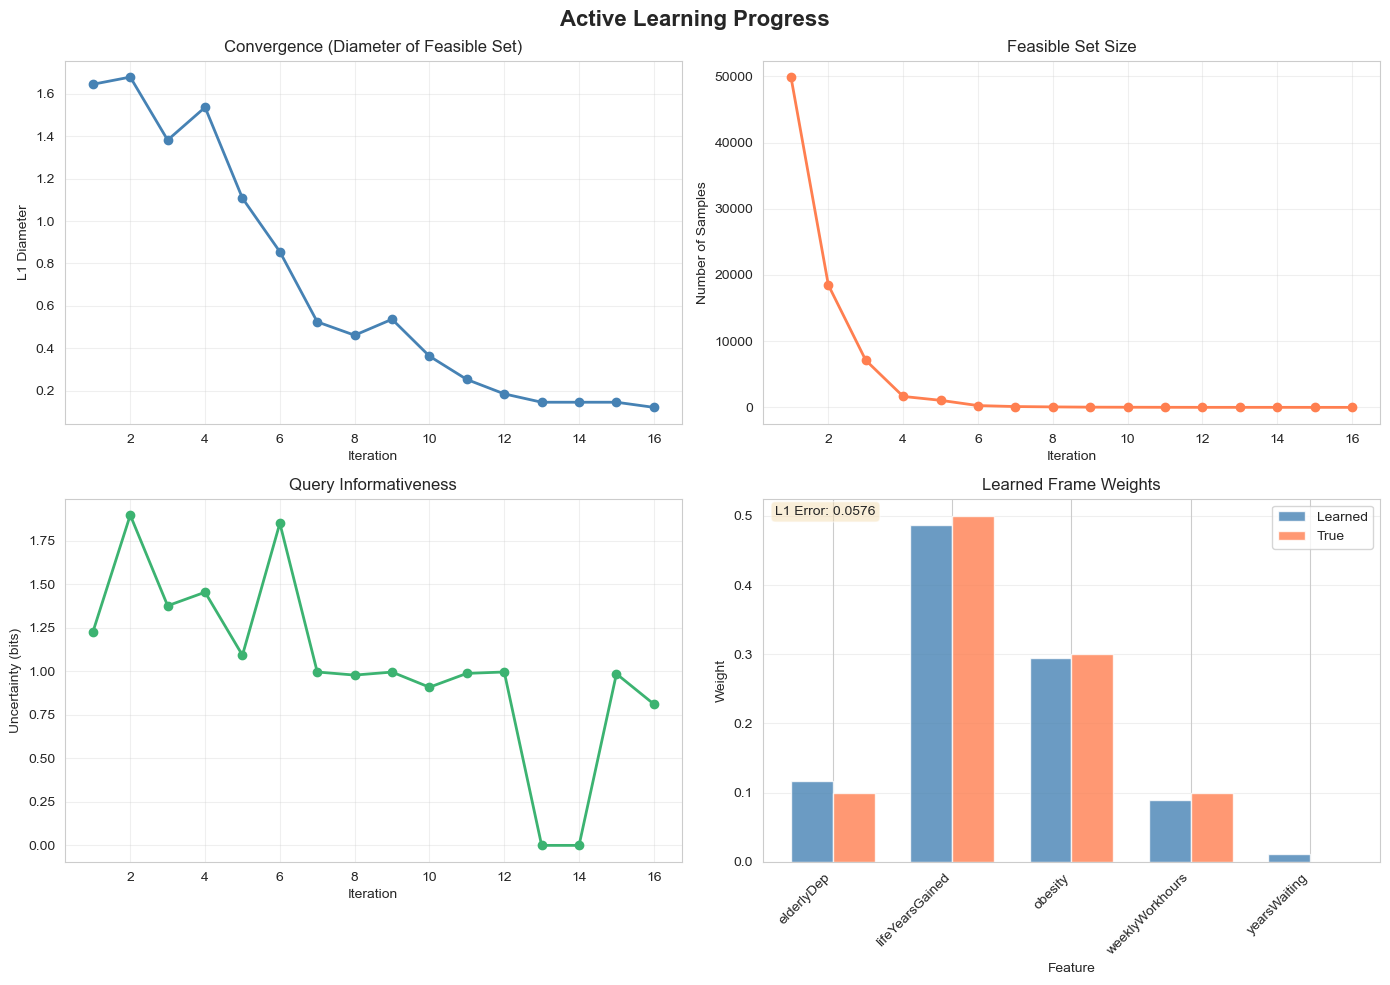


Summary Statistics:
Total iterations: 16
Final diameter: 0.1220
Final sample count: 3
Average uncertainty: 1.034 bits
Total volume removed: 100.0%

Most informative queries:
  1. Iteration 2: 1.897 bits, frames [0, 1, 3], response=right
  2. Iteration 6: 1.850 bits, frames [1, 2, 4], response=right
  3. Iteration 4: 1.454 bits, frames [0, 1, 3, 4], response=left


In [24]:
# Visualization: plot_learning_progress
def plot_learning_progress(history: List[Dict], 
                          learned_weights: np.ndarray,
                          true_weights: Optional[np.ndarray] = None):
    """
    Visualize the active learning progress.
    
    Creates plots showing:
    1. Diameter convergence over iterations
    2. Number of feasible samples over iterations
    3. Query uncertainty over iterations
    4. Learned vs true weights comparison (if true_weights provided)
    
    Parameters:
    -----------
    history : List[Dict]
        History from active_learning_loop
    learned_weights : np.ndarray
        Final learned weights
    true_weights : np.ndarray, optional
        Ground truth weights for comparison
    """
    if len(history) == 0:
        print("No history to plot")
        return
    
    iterations = [h['iteration'] for h in history]
    diameters = [h.get('diameter', h.get('max_distance', 0)) for h in history]
    n_samples_list = [h['n_samples'] for h in history]
    uncertainties = [h['uncertainty'] for h in history]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Active Learning Progress', fontsize=16, fontweight='bold')
    
    # Plot 1: Diameter convergence
    ax = axes[0, 0]
    ax.plot(iterations, diameters, 'o-', linewidth=2, markersize=6, color='steelblue')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('L1 Diameter')
    ax.set_title('Convergence (Diameter of Feasible Set)')
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Number of samples
    ax = axes[0, 1]
    ax.plot(iterations, n_samples_list, 'o-', linewidth=2, markersize=6, color='coral')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Number of Samples')
    ax.set_title('Feasible Set Size')
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Query uncertainty
    ax = axes[1, 0]
    ax.plot(iterations, uncertainties, 'o-', linewidth=2, markersize=6, color='mediumseagreen')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Uncertainty (bits)')
    ax.set_title('Query Informativeness')
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Weight comparison
    ax = axes[1, 1]
    x = np.arange(len(FEATURE_NAMES))
    width = 0.35
    
    ax.bar(x - width/2, learned_weights, width, label='Learned', color='steelblue', alpha=0.8)
    
    if true_weights is not None:
        ax.bar(x + width/2, true_weights, width, label='True', color='coral', alpha=0.8)
        l1_error = np.abs(learned_weights - true_weights).sum()
        ax.text(0.02, 0.98, f'L1 Error: {l1_error:.4f}', 
               transform=ax.transAxes, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Feature')
    ax.set_ylabel('Weight')
    ax.set_title('Learned Frame Weights')
    ax.set_xticks(x)
    ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary Statistics:")
    print(f"{'='*50}")
    print(f"Total iterations: {len(history)}")
    print(f"Final diameter: {diameters[-1]:.4f}")
    print(f"Final sample count: {n_samples_list[-1]}")
    print(f"Average uncertainty: {np.mean(uncertainties):.3f} bits")
    print(f"Total volume removed: {100 * (1 - n_samples_list[-1] / n_samples_list[0]):.1f}%")
    
    # Most informative queries
    print(f"\nMost informative queries:")
    sorted_history = sorted(history, key=lambda h: h['uncertainty'], reverse=True)
    for i, h in enumerate(sorted_history[:3]):
        print(f"  {i+1}. Iteration {h['iteration']}: {h['uncertainty']:.3f} bits, "
              f"frames {sorted(h['active_frames'])}, response={h['response']}")

# Visualize the results from the test run
plot_learning_progress(history_adaptive, learned_adaptive, true_weights)

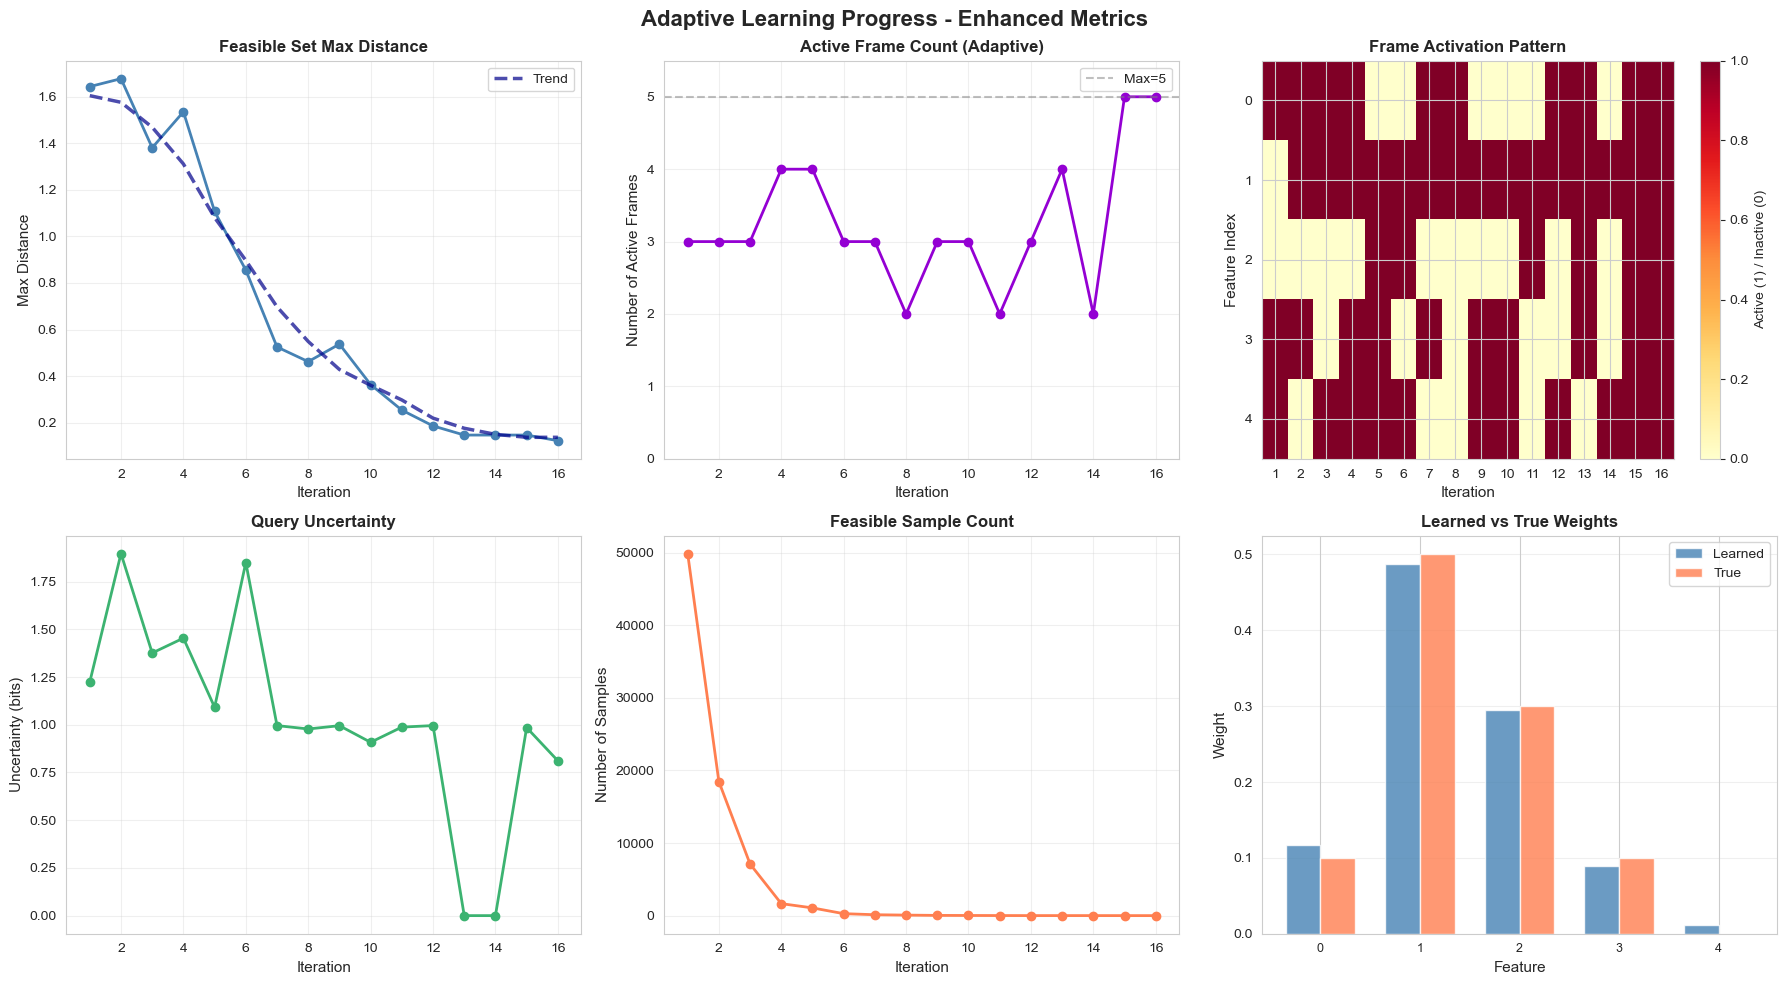


ADAPTIVE QUERYING STATISTICS
Total iterations: 16
Average active frames per query: 3.25
Min active frames: 2
Max active frames: 5
Final max distance: 0.1220
Epsilon-Pareto optimal: False
Final samples: 3
Average uncertainty: 1.034 bits

Frame activation frequency:
  Feature 0: 10/16 queries (62.5%)
  Feature 1: 15/16 queries (93.8%)
  Feature 2: 6/16 queries (37.5%)
  Feature 3: 10/16 queries (62.5%)
  Feature 4: 11/16 queries (68.8%)

L2 error: 0.0272


In [25]:
# Enhanced Visualization for Adaptive Querying
def plot_adaptive_learning_progress(history: List[Dict], 
                                   learned_weights: np.ndarray,
                                   true_weights: Optional[np.ndarray] = None,
                                   feature_names: List[str] = FEATURE_NAMES):
    """
    Enhanced visualization specifically for adaptive querying protocol.
    
    Shows:
    1. Diameter convergence
    2. Number of active frames over time (adaptive-specific)
    3. Frame activation heatmap (adaptive-specific)
    4. Query uncertainty
    5. Number of samples
    6. Weight convergence comparison
    """
    if not history:
        print("No history to plot")
        return
    
    # Extract data from history
    iterations = [h['iteration'] for h in history]
    diameters = [h.get('diameter', h.get('max_distance', 0)) for h in history]
    n_samples_list = [h['n_samples'] for h in history]
    uncertainties = [h['uncertainty'] for h in history]
    
    # Extract adaptive-specific metrics
    n_active_frames = [len(h.get('active_frames', set())) for h in history]
    
    # Create frame activation matrix (iterations x features)
    n_features = len(feature_names)
    frame_activation = np.zeros((len(history), n_features))
    for i, h in enumerate(history):
        active = h.get('active_frames', set())
        for frame_idx in active:
            if frame_idx < n_features:
                frame_activation[i, frame_idx] = 1
    
    # Create figure with 2x3 subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Adaptive Learning Progress - Enhanced Metrics', fontsize=16, fontweight='bold')
    
    # Plot 1: Diameter convergence
    ax = axes[0, 0]
    ax.plot(iterations, diameters, 'o-', linewidth=2, markersize=6, color='steelblue')
    # Add smoothed trend line
    if len(diameters) > 3:
        from scipy.ndimage import uniform_filter1d
        window_size = min(5, len(diameters))
        smoothed = uniform_filter1d(diameters, size=window_size)
        ax.plot(iterations, smoothed, '--', linewidth=2.5, color='darkblue', alpha=0.7, label='Trend')
        ax.legend()
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Max Distance', fontsize=11)
    ax.set_title('Feasible Set Max Distance', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Number of active frames (ADAPTIVE-SPECIFIC)
    ax = axes[0, 1]
    ax.plot(iterations, n_active_frames, 'o-', linewidth=2, markersize=6, color='darkviolet')
    ax.axhline(y=n_features, color='gray', linestyle='--', alpha=0.5, label=f'Max={n_features}')
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Number of Active Frames', fontsize=11)
    ax.set_title('Active Frame Count (Adaptive)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_ylim(0, n_features + 0.5)
    
    # Plot 3: Frame activation heatmap (ADAPTIVE-SPECIFIC)
    ax = axes[0, 2]
    im = ax.imshow(frame_activation.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Feature Index', fontsize=11)
    ax.set_title('Frame Activation Pattern', fontsize=12, fontweight='bold')
    ax.set_yticks(range(n_features))
    ax.set_yticklabels([f'{i}' for i in range(n_features)])
    if len(iterations) <= 20:
        ax.set_xticks(range(len(iterations)))
        ax.set_xticklabels(iterations)
    plt.colorbar(im, ax=ax, label='Active (1) / Inactive (0)')
    
    # Plot 4: Query uncertainty
    ax = axes[1, 0]
    ax.plot(iterations, uncertainties, 'o-', linewidth=2, markersize=6, color='mediumseagreen')
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Uncertainty (bits)', fontsize=11)
    ax.set_title('Query Uncertainty', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Plot 5: Number of samples
    ax = axes[1, 1]
    ax.plot(iterations, n_samples_list, 'o-', linewidth=2, markersize=6, color='coral')
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Number of Samples', fontsize=11)
    ax.set_title('Feasible Sample Count', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Plot 6: Weight comparison
    ax = axes[1, 2]
    x_pos = np.arange(len(feature_names))
    width = 0.35
    
    bars1 = ax.bar(x_pos - width/2, learned_weights, width, label='Learned', color='steelblue', alpha=0.8)
    if true_weights is not None:
        bars2 = ax.bar(x_pos + width/2, true_weights, width, label='True', color='coral', alpha=0.8)
    
    ax.set_xlabel('Feature', fontsize=11)
    ax.set_ylabel('Weight', fontsize=11)
    ax.set_title('Learned vs True Weights', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(range(len(feature_names)), fontsize=9)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print adaptive statistics
    print("\n" + "="*60)
    print("ADAPTIVE QUERYING STATISTICS")
    print("="*60)
    print(f"Total iterations: {len(history)}")
    print(f"Average active frames per query: {np.mean(n_active_frames):.2f}")
    print(f"Min active frames: {np.min(n_active_frames)}")
    print(f"Max active frames: {np.max(n_active_frames)}")
    print(f"Final max distance: {diameters[-1]:.4f}")
    if history[-1].get("is_epsilon_pareto") is not None:
        print(f"Epsilon-Pareto optimal: {history[-1]['is_epsilon_pareto']}")
    print(f"Final samples: {n_samples_list[-1]}")
    print(f"Average uncertainty: {np.mean(uncertainties):.3f} bits")
    
    # Frame-specific statistics
    print("\nFrame activation frequency:")
    activation_counts = frame_activation.sum(axis=0)
    for i, count in enumerate(activation_counts):
        pct = 100 * count / len(history)
        print(f"  Feature {i}: {int(count)}/{len(history)} queries ({pct:.1f}%)")
    
    if true_weights is not None:
        l2_error = np.linalg.norm(learned_weights - true_weights)
        print(f"\nL2 error: {l2_error:.4f}")
    
    print("="*60)

# Call the enhanced visualization
plot_adaptive_learning_progress(history_adaptive, learned_adaptive, true_weights)


METHOD COMPARISON: Your Method vs Bradley-Terry

Transcript: 16 queries

Response distribution:
  incomparable: 2 (12.5%)
  indifferent: 7 (43.8%)
  left: 5 (31.2%)
  right: 2 (12.5%)

----------------------------------------------------------------------
Bradley-Terry fitting on 7 decisive comparisons (out of 16 total)
  Left preferred: 5 (71.4%)
  Right preferred: 2 (28.6%)

----------------------------------------------------------------------
RESULTS
----------------------------------------------------------------------

Learned Weights:
Feature              True       Your Method     Bradley-Terry  
------------------------------------------------------------
elderlyDep           0.100      0.117           0.141          
lifeYearsGained      0.500      0.487           0.785          
obesity              0.300      0.295           0.000          
weeklyWorkhours      0.100      0.089           0.062          
yearsWaiting         0.000      0.012           0.012          

Error

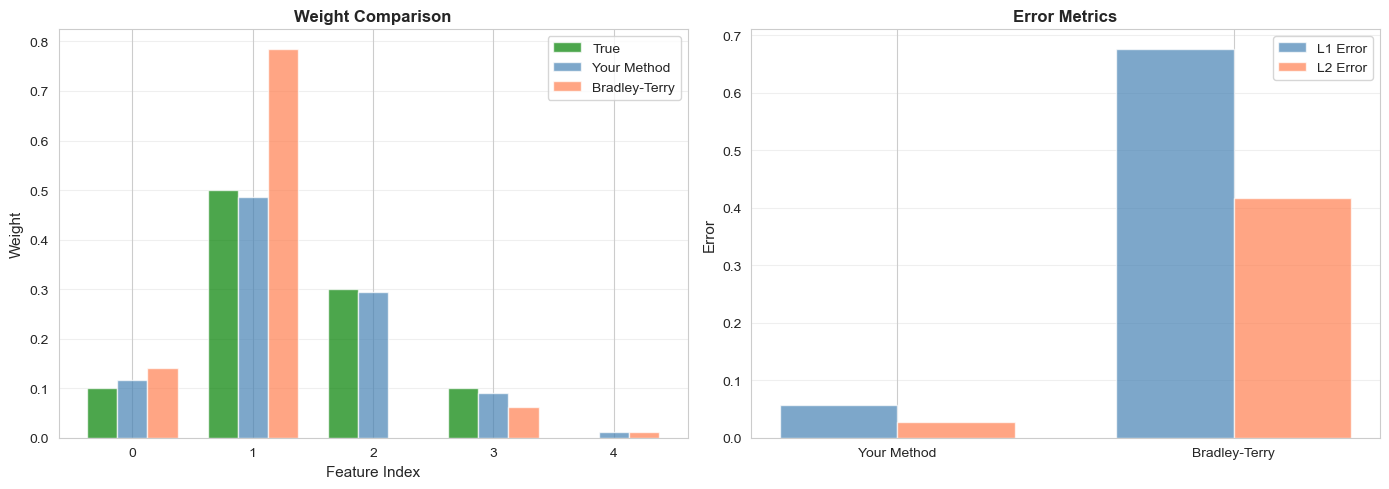

In [26]:
# Bradley-Terry Model Comparison
from typing import List, Tuple
from scipy.optimize import minimize
from scipy.special import expit  # sigmoid function

def extract_transcript(history: List[Dict]) -> List[Tuple[PairwiseQuery, str]]:
    """
    Extract the query transcript from learning history.
    
    Returns:
    --------
    transcript : List[Tuple[PairwiseQuery, str]]
        List of (query, response) pairs
    """
    transcript = []
    for h in history:
        query = h['query']
        response = h['response']
        transcript.append((query, response))
    return transcript

def fit_bradley_terry(transcript: List[Tuple[PairwiseQuery, str]], 
                     n_features: int = 5,
                     feature_names: List[str] = FEATURE_NAMES) -> np.ndarray:
    """
    Fit Bradley-Terry model on pairwise comparison transcript.
    
    Bradley-Terry assumes: P(left > right) = exp(utility_left) / (exp(utility_left) + exp(utility_right))
    where utility = w^T x (linear in features)
    
    This is essentially logistic regression on the feature differences.
    
    Parameters:
    -----------
    transcript : List[Tuple[PairwiseQuery, str]]
        Pairwise queries and responses
    n_features : int
        Number of features
    
    Returns:
    --------
    weights : np.ndarray
        Learned feature weights (normalized to simplex)
    """
    # Convert to feature differences and binary outcomes
    X = []  # Feature differences (left - right)
    y = []  # Binary outcomes (1 if left preferred, 0 if right preferred)
    
    for query, response in transcript:
        # Get feature vectors
        left_features = query.patient_left.to_array()
        right_features = query.patient_right.to_array()
        
        # Skip indifferent and incomparable responses for Bradley-Terry
        # (standard BT only handles strict preferences)
        if response == 'left':
            X.append(left_features - right_features)
            y.append(1)
        elif response == 'right':
            X.append(left_features - right_features)
            y.append(0)
        # Skip 'indifferent' and 'incomparable'
    
    if len(X) == 0:
        print("Warning: No decisive comparisons (left/right) in transcript!")
        return np.ones(n_features) / n_features
    
    X = np.array(X)
    y = np.array(y)
    
    print(f"Bradley-Terry fitting on {len(y)} decisive comparisons (out of {len(transcript)} total)")
    print(f"  Left preferred: {np.sum(y)} ({100*np.mean(y):.1f}%)")
    print(f"  Right preferred: {len(y) - np.sum(y)} ({100*(1-np.mean(y)):.1f}%)")
    
    # Negative log-likelihood for Bradley-Terry
    def neg_log_likelihood(w):
        # P(left > right | x) = sigmoid(w^T (x_left - x_right))
        logits = X @ w
        # Cross-entropy loss
        loss = -np.mean(y * np.log(expit(logits) + 1e-10) + 
                       (1 - y) * np.log(1 - expit(logits) + 1e-10))
        # Add small L2 regularization to prevent overfitting
        loss += 0.01 * np.sum(w**2)
        return loss
    
    # Optimize
    w_init = np.ones(n_features) / n_features
    result = minimize(neg_log_likelihood, w_init, method='L-BFGS-B')
    
    if not result.success:
        print(f"Warning: Optimization did not converge: {result.message}")
    
    weights_raw = result.x
    
    # Project to non-negative and normalize to simplex
    weights = np.maximum(weights_raw, 0)
    weights = weights / (np.sum(weights) + 1e-10)
    
    return weights

def compare_methods(history: List[Dict],
                   learned_weights: np.ndarray,
                   true_weights: np.ndarray,
                   feature_names: List[str] = FEATURE_NAMES):
    """
    Compare your method vs Bradley-Terry on the same transcript.
    """
    print("\n" + "="*70)
    print("METHOD COMPARISON: Your Method vs Bradley-Terry")
    print("="*70)
    
    # Extract transcript
    transcript = extract_transcript(history)
    print(f"\nTranscript: {len(transcript)} queries")
    
    # Count response types
    response_counts = {}
    for _, response in transcript:
        response_counts[response] = response_counts.get(response, 0) + 1
    
    print("\nResponse distribution:")
    for resp, count in sorted(response_counts.items()):
        print(f"  {resp}: {count} ({100*count/len(transcript):.1f}%)")
    
    # Fit Bradley-Terry
    print("\n" + "-"*70)
    bt_weights = fit_bradley_terry(transcript, n_features=len(feature_names))
    
    # Compute errors
    your_l1 = np.linalg.norm(learned_weights - true_weights, ord=1)
    your_l2 = np.linalg.norm(learned_weights - true_weights, ord=2)
    
    bt_l1 = np.linalg.norm(bt_weights - true_weights, ord=1)
    bt_l2 = np.linalg.norm(bt_weights - true_weights, ord=2)
    
    print("\n" + "-"*70)
    print("RESULTS")
    print("-"*70)
    
    print("\nLearned Weights:")
    print(f"{'Feature':<20} {'True':<10} {'Your Method':<15} {'Bradley-Terry':<15}")
    print("-"*60)
    for i, name in enumerate(feature_names):
        print(f"{name:<20} {true_weights[i]:<10.3f} {learned_weights[i]:<15.3f} {bt_weights[i]:<15.3f}")
    
    print("\nError Metrics:")
    print(f"{'Method':<20} {'L1 Error':<15} {'L2 Error':<15}")
    print("-"*50)
    print(f"{'Your Method':<20} {your_l1:<15.4f} {your_l2:<15.4f}")
    print(f"{'Bradley-Terry':<20} {bt_l1:<15.4f} {bt_l2:<15.4f}")
    
    if your_l2 < bt_l2:
        improvement = 100 * (bt_l2 - your_l2) / bt_l2
        print(f"\n✓ Your method is {improvement:.1f}% more accurate (L2)")
    else:
        diff = 100 * (your_l2 - bt_l2) / bt_l2
        print(f"\n✗ Bradley-Terry is {diff:.1f}% more accurate (L2)")
    
    print("="*70)
    
    # Create comparison plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Weight comparison
    ax = axes[0]
    x_pos = np.arange(len(feature_names))
    width = 0.25
    
    ax.bar(x_pos - width, true_weights, width, label='True', color='green', alpha=0.7)
    ax.bar(x_pos, learned_weights, width, label='Your Method', color='steelblue', alpha=0.7)
    ax.bar(x_pos + width, bt_weights, width, label='Bradley-Terry', color='coral', alpha=0.7)
    
    ax.set_xlabel('Feature Index', fontsize=11)
    ax.set_ylabel('Weight', fontsize=11)
    ax.set_title('Weight Comparison', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(range(len(feature_names)))
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Error comparison
    ax = axes[1]
    methods = ['Your Method', 'Bradley-Terry']
    l1_errors = [your_l1, bt_l1]
    l2_errors = [your_l2, bt_l2]
    
    x_pos = np.arange(len(methods))
    width = 0.35
    
    ax.bar(x_pos - width/2, l1_errors, width, label='L1 Error', color='steelblue', alpha=0.7)
    ax.bar(x_pos + width/2, l2_errors, width, label='L2 Error', color='coral', alpha=0.7)
    
    ax.set_ylabel('Error', fontsize=11)
    ax.set_title('Error Metrics', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(methods)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return bt_weights

# Run the comparison
bt_weights = compare_methods(history_adaptive, learned_adaptive, true_weights)


CONVERGENCE DIAGNOSTIC

Target: epsilon = 0.1
Final max distance: 0.1220
Converged: False

✗ NOT CONVERGED - Gap: 0.0220 (22.0% over threshold)

Total iterations: 16

Response distribution:
  left           :   5 ( 31.2%)
  right          :   2 ( 12.5%)
  indifferent    :   7 ( 43.8%)
  incomparable   :   2 ( 12.5%)

⚠️  HIGH non-decisive responses (56.2%)
   This slows convergence - consider:
   1. Increasing max_iterations
   2. Adjusting tau/tau_prime thresholds
   3. Relaxing epsilon_pareto tolerance

Distance progression:
  Initial: 1.6444
  Final:   0.1220
  Reduction: 1.5223 (92.6%)

Estimated iterations needed: ~1 more (at recent convergence rate)
Suggested max_iterations: 22


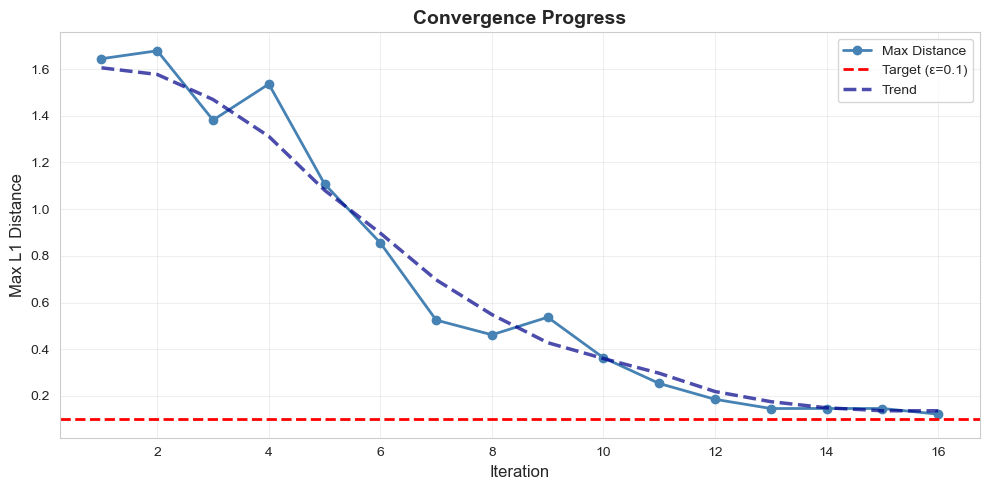

In [27]:
# Convergence Diagnostic
def analyze_convergence(history: List[Dict], epsilon: float = 0.15):
    """
    Analyze why the algorithm didn't reach epsilon-Pareto optimality.
    """
    print("\n" + "="*70)
    print("CONVERGENCE DIAGNOSTIC")
    print("="*70)
    
    final = history[-1]
    final_distance = final['max_distance']
    final_converged = final['is_epsilon_pareto']
    
    print(f"\nTarget: epsilon = {epsilon}")
    print(f"Final max distance: {final_distance:.4f}")
    print(f"Converged: {final_converged}")
    
    if not final_converged:
        gap = final_distance - epsilon
        print(f"\n✗ NOT CONVERGED - Gap: {gap:.4f} ({100*gap/epsilon:.1f}% over threshold)")
    
    # Response type analysis
    response_counts = {'left': 0, 'right': 0, 'indifferent': 0, 'incomparable': 0}
    for h in history:
        response_counts[h['response']] += 1
    
    total = len(history)
    print(f"\nTotal iterations: {total}")
    print("\nResponse distribution:")
    for resp in ['left', 'right', 'indifferent', 'incomparable']:
        count = response_counts[resp]
        pct = 100 * count / total
        print(f"  {resp:15s}: {count:3d} ({pct:5.1f}%)")
    
    # Check if indifferent/incomparable are blocking progress
    non_decisive = response_counts['indifferent'] + response_counts['incomparable']
    non_decisive_pct = 100 * non_decisive / total
    
    if non_decisive_pct > 30:
        print(f"\n⚠️  HIGH non-decisive responses ({non_decisive_pct:.1f}%)")
        print("   This slows convergence - consider:")
        print("   1. Increasing max_iterations")
        print("   2. Adjusting tau/tau_prime thresholds")
        print("   3. Relaxing epsilon_pareto tolerance")
    
    # Distance over time
    distances = [h['max_distance'] for h in history]
    
    print(f"\nDistance progression:")
    print(f"  Initial: {distances[0]:.4f}")
    print(f"  Final:   {distances[-1]:.4f}")
    print(f"  Reduction: {distances[0] - distances[-1]:.4f} ({100*(distances[0]-distances[-1])/distances[0]:.1f}%)")
    
    # Estimate iterations needed
    if len(distances) > 5:
        recent_rate = (distances[-5] - distances[-1]) / 5
        if recent_rate > 0:
            remaining = final_distance - epsilon
            est_iters = remaining / recent_rate
            print(f"\nEstimated iterations needed: ~{int(est_iters)} more (at recent convergence rate)")
            print(f"Suggested max_iterations: {total + int(est_iters) + 5}")
    
    # Plot convergence
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    
    iterations = [h['iteration'] for h in history]
    ax.plot(iterations, distances, 'o-', linewidth=2, markersize=6, color='steelblue', label='Max Distance')
    ax.axhline(y=epsilon, color='red', linestyle='--', linewidth=2, label=f'Target (ε={epsilon})')
    
    # Add smoothed trend if enough data
    if len(distances) > 3:
        from scipy.ndimage import uniform_filter1d
        smoothed = uniform_filter1d(distances, size=min(5, len(distances)))
        ax.plot(iterations, smoothed, '--', linewidth=2.5, color='darkblue', alpha=0.7, label='Trend')
    
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Max L1 Distance', fontsize=12)
    ax.set_title('Convergence Progress', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("="*70)

# Run diagnostic
analyze_convergence(history_adaptive, epsilon=0.1)

In [ ]:
# Experiment: Impact of number of candidates on convergence
def run_convergence_experiment(k_values: List[int],
                               n_trials: int = 5,
                               n_initial_samples: int = 1000,
                               convergence_diameter: float = 0.15,
                               max_iterations: int = 50,
                               oracle_weights: Optional[np.ndarray] = None) -> Dict:
    """
    Run experiments to measure how the number of candidates (K) affects convergence.
    
    For each K value:
    - Run multiple trials with different random seeds
    - Track: iterations to convergence, final L1 error, computational time
    
    Parameters:
    -----------
    k_values : List[int]
        Different values of K (num_candidates) to test
    n_trials : int
        Number of trials per K value
    n_initial_samples : int
        Initial samples for each trial
    convergence_diameter : float
        Convergence threshold
    max_iterations : int
        Maximum iterations per trial
    oracle_weights : np.ndarray, optional
        Ground truth weights (if None, uses random)
    
    Returns:
    --------
    results : Dict
        Experimental results with keys:
        - 'k_values': list of K values tested
        - 'convergence_iters': dict mapping K -> list of iterations to converge
        - 'l1_errors': dict mapping K -> list of final L1 errors
        - 'times': dict mapping K -> list of execution times (seconds)
    """
    import time
    
    # Generate ground truth if not provided
    if oracle_weights is None:
        oracle_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])
    
    results = {
        'k_values': k_values,
        'convergence_iters': {k: [] for k in k_values},
        'l1_errors': {k: [] for k in k_values},
        'times': {k: [] for k in k_values},
        'final_diameters': {k: [] for k in k_values}
    }
    
    print(f"Running convergence experiments...")
    print(f"K values: {k_values}")
    print(f"Trials per K: {n_trials}")
    print(f"Oracle weights: {oracle_weights}\n")
    
    for k in k_values:
        print(f"Testing K = {k}:")
        
        for trial in range(n_trials):
            # Set different random seed for each trial
            np.random.seed(42 + trial)
            
            start_time = time.time()
            
            # Run active learning
            learned, history = active_learning_loop(
                n_initial_samples=n_initial_samples,
                convergence_diameter=convergence_diameter,
                max_iterations=max_iterations,
                n_candidates=k,
                oracle_weights=oracle_weights,
                verbose=False
            )
            
            elapsed_time = time.time() - start_time
            
            # Extract metrics
            n_iters = len(history)
            l1_error = np.abs(learned - oracle_weights).sum()
            final_diameter = history[-1]['diameter'] if history else float('inf')
            
            results['convergence_iters'][k].append(n_iters)
            results['l1_errors'][k].append(l1_error)
            results['times'][k].append(elapsed_time)
            results['final_diameters'][k].append(final_diameter)
            
            print(f"  Trial {trial+1}/{n_trials}: {n_iters} iters, "
                  f"L1={l1_error:.4f}, time={elapsed_time:.2f}s")
        
        # Print summary for this K
        avg_iters = np.mean(results['convergence_iters'][k])
        avg_error = np.mean(results['l1_errors'][k])
        avg_time = np.mean(results['times'][k])
        
        print(f"  → Average: {avg_iters:.1f} iters, L1={avg_error:.4f}, time={avg_time:.2f}s\n")
    
    return results

# Run the experiment
# Test K values: 10, 50, 100, 200, 500
k_test_values = [10, 50, 100, 200, 500]
oracle_weights_test = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

experiment_results = run_convergence_experiment(
    k_values=k_test_values,
    n_trials=5,
    n_initial_samples=1000,
    convergence_diameter=0.15,
    max_iterations=50,
    oracle_weights=oracle_weights_test
)

Running convergence experiments...
K values: [10, 50, 100, 200, 500]
Trials per K: 5
Oracle weights: [0.1 0.5 0.1 0.1 0.2]

Testing K = 10:
  Trial 1/5: 9 iters, L1=0.2304, time=0.03s
  Trial 2/5: 9 iters, L1=0.2304, time=0.03s
  Trial 3/5: 9 iters, L1=0.2304, time=0.03s
  Trial 4/5: 9 iters, L1=0.2304, time=0.03s
  Trial 5/5: 9 iters, L1=0.2304, time=0.03s
  → Average: 9.0 iters, L1=0.2304, time=0.03s

Testing K = 50:
  Trial 1/5: 6 iters, L1=0.3020, time=0.07s
  Trial 2/5: 6 iters, L1=0.3020, time=0.07s
  Trial 3/5: 6 iters, L1=0.3020, time=0.07s
  Trial 4/5: 6 iters, L1=0.3020, time=0.07s
  Trial 5/5: 6 iters, L1=0.3020, time=0.07s
  → Average: 6.0 iters, L1=0.3020, time=0.07s

Testing K = 100:
  Trial 1/5: 6 iters, L1=0.2137, time=0.10s
  Trial 2/5: 6 iters, L1=0.2137, time=0.10s
  Trial 3/5: 6 iters, L1=0.2137, time=0.15s
  Trial 4/5: 6 iters, L1=0.2137, time=0.11s
  Trial 5/5: 6 iters, L1=0.2137, time=0.10s
  → Average: 6.0 iters, L1=0.2137, time=0.11s

Testing K = 200:
  Trial 1

## Solutions to Improve Convergence

If the algorithm isn't reaching epsilon-Pareto optimality, try these fixes:

### Option 1: Increase max_iterations (Recommended)
```python
learned_adaptive, history_adaptive = active_learning_loop_adaptive(
    n_initial_samples=1000,
    epsilon_pareto=0.15,
    max_iterations=30,  # ← Increase from 15 to 30+
    n_candidates=20,
    top_k_uncertain=3,
    oracle_weights=true_weights,
    verbose=True
)
```

### Option 2: Relax epsilon threshold
```python
learned_adaptive, history_adaptive = active_learning_loop_adaptive(
    epsilon_pareto=0.25,  # ← Relax from 0.15 to 0.25
    max_iterations=15,
    ...
)
```

### Option 3: Adjust decision thresholds
Making queries more decisive (fewer indifferent/incomparable responses):
```python
# Lower tau → more queries are "intense" enough
TAU = 0.05  # instead of 0.1

# Lower tau_prime → easier to resolve differences
TAU_PRIME = 0.15  # instead of 0.2
```

### Option 4: Generate better queries
```python
learned_adaptive, history_adaptive = active_learning_loop_adaptive(
    n_candidates=50,  # ← Increase from 20 to 50 (more options to choose from)
    ...
)
```

In [ ]:
# Comparative Experiment: Baseline vs Adaptive
def run_baseline_vs_adaptive_experiment(n_trials: int = 10,
                                       n_initial_samples: int = 100000,
                                       epsilon: float = 0.1,
                                       max_iterations: int = 500,
                                       n_candidates: int = 50,
                                       oracle_weights: Optional[np.ndarray] = None) -> Dict:
    """
    Compare baseline (random candidates) vs adaptive (uncertainty-targeted) approaches.
    
    For each approach:
    - Run multiple trials with different random seeds
    - Track: iterations to convergence, final L1 error, computational time
    
    Parameters:
    -----------
    n_trials : int
        Number of trials per approach
    n_initial_samples : int
        Initial samples for each trial
    epsilon : float
        Convergence threshold (used for both diameter and ε-Pareto)
    max_iterations : int
        Maximum iterations per trial
    n_candidates : int
        Number of candidates per iteration
    oracle_weights : np.ndarray, optional
        Ground truth weights (if None, uses default)
    
    Returns:
    --------
    results : Dict
        Experimental results comparing baseline vs adaptive
    """
    import time
    
    # Generate ground truth if not provided
    if oracle_weights is None:
        oracle_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])
    
    results = {
        'baseline': {
            'iters': [],
            'l1_errors': [],
            'times': [],
            'final_distances': []
        },
        'adaptive': {
            'iters': [],
            'l1_errors': [],
            'times': [],
            'final_distances': []
        }
    }
    
    print(f"Running Baseline vs Adaptive Comparison")
    print(f"{'='*60}")
    print(f"Trials per approach: {n_trials}")
    print(f"Oracle weights: {oracle_weights}")
    print(f"ε = {epsilon}\n")
    
    # Run baseline trials
    print(f"BASELINE (random candidates, diameter stopping):")
    for trial in range(n_trials):
        np.random.seed(42 + trial)
        
        start_time = time.time()
        
        # Run baseline (uses old active_learning_loop with random candidates)
        learned, history = active_learning_loop(
            n_initial_samples=n_initial_samples,
            convergence_diameter=epsilon,
            max_iterations=max_iterations,
            n_candidates=n_candidates,
            oracle_weights=oracle_weights,
            verbose=False
        )
        
        elapsed_time = time.time() - start_time
        
        # Extract metrics
        n_iters = len(history)
        l1_error = np.abs(learned - oracle_weights).sum()
        final_dist = history[-1]['diameter'] if history else float('inf')
        
        results['baseline']['iters'].append(n_iters)
        results['baseline']['l1_errors'].append(l1_error)
        results['baseline']['times'].append(elapsed_time)
        results['baseline']['final_distances'].append(final_dist)
        
        print(f"  Trial {trial+1}/{n_trials}: {n_iters} iters, L1={l1_error:.4f}, time={elapsed_time:.2f}s")
    
    avg_iters_base = np.mean(results['baseline']['iters'])
    avg_error_base = np.mean(results['baseline']['l1_errors'])
    avg_time_base = np.mean(results['baseline']['times'])
    print(f"  → Average: {avg_iters_base:.1f} iters, L1={avg_error_base:.4f}, time={avg_time_base:.2f}s\n")
    
    # Run adaptive trials
    print(f"ADAPTIVE (uncertainty-targeted, ε-Pareto stopping):")
    for trial in range(n_trials):
        np.random.seed(42 + trial)
        
        start_time = time.time()
        
        # Run adaptive
        learned, history = active_learning_loop_adaptive(
            n_initial_samples=n_initial_samples,
            epsilon_pareto=epsilon,
            max_iterations=max_iterations,
            n_candidates=n_candidates,
            top_k_uncertain=3,
            oracle_weights=oracle_weights,
            verbose=False
        )
        
        elapsed_time = time.time() - start_time
        
        # Extract metrics
        n_iters = len(history)
        l1_error = np.abs(learned - oracle_weights).sum()
        final_dist = history[-1]['max_distance'] if history else float('inf')
        
        results['adaptive']['iters'].append(n_iters)
        results['adaptive']['l1_errors'].append(l1_error)
        results['adaptive']['times'].append(elapsed_time)
        results['adaptive']['final_distances'].append(final_dist)
        
        print(f"  Trial {trial+1}/{n_trials}: {n_iters} iters, L1={l1_error:.4f}, time={elapsed_time:.2f}s")
    
    avg_iters_adapt = np.mean(results['adaptive']['iters'])
    avg_error_adapt = np.mean(results['adaptive']['l1_errors'])
    avg_time_adapt = np.mean(results['adaptive']['times'])
    print(f"  → Average: {avg_iters_adapt:.1f} iters, L1={avg_error_adapt:.4f}, time={avg_time_adapt:.2f}s\n")
    
    # Print comparison
    print(f"{'='*60}")
    print(f"COMPARISON:")
    print(f"{'='*60}")
    
    iter_improvement = (avg_iters_base - avg_iters_adapt) / avg_iters_base * 100
    error_improvement = (avg_error_base - avg_error_adapt) / avg_error_base * 100
    time_improvement = (avg_time_base - avg_time_adapt) / avg_time_base * 100
    
    print(f"Sample Complexity (iterations):")
    print(f"  Baseline: {avg_iters_base:.1f} ± {np.std(results['baseline']['iters']):.1f}")
    print(f"  Adaptive: {avg_iters_adapt:.1f} ± {np.std(results['adaptive']['iters']):.1f}")
    print(f"  Improvement: {iter_improvement:+.1f}% {'(adaptive better)' if iter_improvement > 0 else '(baseline better)'}")
    print()
    
    print(f"Accuracy (L1 error):")
    print(f"  Baseline: {avg_error_base:.4f} ± {np.std(results['baseline']['l1_errors']):.4f}")
    print(f"  Adaptive: {avg_error_adapt:.4f} ± {np.std(results['adaptive']['l1_errors']):.4f}")
    print(f"  Improvement: {error_improvement:+.1f}% {'(adaptive better)' if error_improvement > 0 else '(baseline better)'}")
    print()
    
    print(f"Computational Time (seconds):")
    print(f"  Baseline: {avg_time_base:.2f} ± {np.std(results['baseline']['times']):.2f}")
    print(f"  Adaptive: {avg_time_adapt:.2f} ± {np.std(results['adaptive']['times']):.2f}")
    print(f"  Difference: {time_improvement:+.1f}% {'(adaptive faster)' if time_improvement > 0 else '(baseline faster)'}")
    print()
    
    # Overall efficiency
    eff_base = 1.0 / (avg_error_base * avg_time_base)
    eff_adapt = 1.0 / (avg_error_adapt * avg_time_adapt)
    eff_improvement = (eff_adapt - eff_base) / eff_base * 100
    
    print(f"Overall Efficiency (1 / (error × time)):")
    print(f"  Baseline: {eff_base:.2f}")
    print(f"  Adaptive: {eff_adapt:.2f}")
    print(f"  Improvement: {eff_improvement:+.1f}% {'(adaptive better)' if eff_improvement > 0 else '(baseline better)'}")
    
    return results

# Run comparison experiment
# comparison_results = run_baseline_vs_adaptive_experiment(
#     n_trials=10,
#     n_initial_samples=50000,
#     epsilon=0.10,
#     max_iterations=500,
#     n_candidates=50,
#     oracle_weights=np.array([0.1, 0.5, 0.1, 0.1, 0.2])
# )

Running Baseline vs Adaptive Comparison
Trials per approach: 10
Oracle weights: [0.1 0.5 0.1 0.1 0.2]
ε = 0.1

BASELINE (random candidates, diameter stopping):
  Trial 1/10: 17 iters, L1=0.1210, time=43.03s
  Trial 2/10: 17 iters, L1=0.1210, time=37.32s
  Trial 3/10: 17 iters, L1=0.1210, time=16.22s
  Trial 4/10: 17 iters, L1=0.1210, time=12.23s
  Trial 5/10: 17 iters, L1=0.1210, time=13.51s
  Trial 6/10: 17 iters, L1=0.1210, time=10.87s
  Trial 7/10: 17 iters, L1=0.1210, time=15.66s
  Trial 8/10: 17 iters, L1=0.1210, time=14.79s
  Trial 9/10: 17 iters, L1=0.1210, time=12.10s
  Trial 10/10: 17 iters, L1=0.1210, time=12.84s
  → Average: 17.0 iters, L1=0.1210, time=18.86s

ADAPTIVE (uncertainty-targeted, ε-Pareto stopping):
  Trial 1/10: 19 iters, L1=0.0749, time=1.54s
  Trial 2/10: 19 iters, L1=0.0749, time=1.45s
  Trial 3/10: 19 iters, L1=0.0749, time=1.64s
  Trial 4/10: 19 iters, L1=0.0749, time=1.59s
  Trial 5/10: 19 iters, L1=0.0749, time=1.47s
  Trial 6/10: 19 iters, L1=0.0749, tim